# π0 LoRA 파인튜닝 해설 노트북

> **목적:** Piper 로봇의 LeRobot v3 데이터를 π0가 읽을 수 있는 형태로 바꾸고, 공식 OpenPI LoRA 설정으로 **한 번의 실제 학습과 저장·복원까지** 직접 확인한다.

이 노트북은 단순히 실행 명령만 모아둔 파일이 아니다. 긴 production 학습을 시작하기 전에 데이터 한 샘플이 어떤 모양으로 바뀌고, 어떤 파라미터가 학습되며, checkpoint가 무엇을 저장하는지 한 단계씩 분해해 보는 **실행 가능한 설명서**다.

> **코드 기준 경고:** 이 노트북의 Cell 10~16은 production 코드가 정리되기 전의 step-1 smoke 구현을 셀 안에 복제한 기록이다. 현재 source of truth는 `scripts/training/train.py → piper_vla.training.trainer.execute() → piper_vla.training.diagnostics.run_training_loop_with_diagnostics()`이며, 노트북의 `r001`/step-1 저장·복원 코드는 현재 run에 재실행하지 않는다.

## 전체 흐름 먼저 보기

```text
LeRobot v3
  ├─ Parquet: state, action, episode 정보
  └─ MP4: third-person, wrist 영상
          │
          ▼
PiperV3Dataset                ← v3 파일을 읽는 공통 adapter
          │  raw 7D state / 50×7 action / 2 cameras / prompt
          ▼
Piper → π0 data transform
  ├─ joint 1~6: absolute action → delta action
  ├─ gripper: absolute action 유지
  ├─ mean/std normalization
  ├─ image 480×640 → 224×224
  ├─ prompt → token 48개
  └─ state/action 7D → model 내부 32D
          │
          ▼
π0 LoRA TrainState
  ├─ 동결: 두 Gemma expert의 원본 LLM 파라미터
  └─ 학습: LoRA + vision encoder + action/state projection
          │
          ▼
JIT train step → Orbax checkpoint → fresh-kernel restore
```

## 먼저 알아둘 단어

| 단어 | 이 노트북에서의 쉬운 뜻 |
|---|---|
| **state** | 지금 로봇의 관절 6개와 gripper 위치, 총 7개 숫자 |
| **action** | 로봇에게 다음에 가라고 지시할 목표 값 |
| **absolute action** | 목표 관절 위치 그 자체 |
| **delta action** | 현재 위치에서 얼마나 움직일지를 나타낸 차이값 |
| **action horizon** | 한 번에 예측할 미래 action 개수. 여기서는 50개 |
| **normalization** | 축마다 다른 숫자 범위를 비슷한 크기로 맞추는 작업 |
| **padding** | 모델 규격에 맞추려고 사용하지 않는 뒤쪽 차원을 0으로 채우는 작업 |
| **LoRA** | 큰 원본 행렬은 고정하고 작은 추가 행렬을 학습하는 방법 |
| **JIT compile** | 첫 실행 때 GPU용 계산 프로그램을 만든 뒤 같은 모양의 다음 실행을 빠르게 만드는 과정 |
| **TrainState** | 모델 파라미터, optimizer 상태, 현재 step을 함께 보관하는 학습 상태 |
| **checkpoint** | TrainState와 추론용 파라미터를 디스크에 저장한 복구 지점 |
| **fine-tuning** | 이미 학습된 π0를 Piper 데이터에 맞게 추가 학습하는 과정 |
| **parameter** | 모델이 학습하며 바꾸거나 동결해 두는 내부 숫자 |
| **JAX** | 배열 계산을 GPU용 코드로 compile하고 gradient를 자동 계산하는 라이브러리 |
| **Parquet** | state/action 같은 표 형태 숫자를 저장하는 파일 형식 |
| **batch** | 한 train step에서 함께 처리하는 sample 묶음 |
| **gradient** | loss를 줄이려면 parameter를 어느 방향으로 바꿔야 하는지 나타내는 값 |
| **optimizer** | gradient를 이용해 parameter를 실제로 갱신하는 규칙. 여기서는 AdamW |
| **epoch** | 전체 dataset sample을 평균 한 번씩 사용한 학습량 |
| **Orbax** | JAX TrainState를 안전하게 저장·복원하는 checkpoint 도구 |
| **bfloat16 / float32** | 각각 메모리를 줄이는 16-bit 표현과 학습 갱신을 안정적으로 보관하는 32-bit 표현 |

## 실행 강도와 안전 구간

| 셀 | 하는 일 | GPU/디스크 영향 |
|---|---|---|
| 1~11 | 환경, 데이터, 통계, transform, loader 이해 | 모델 가중치 미로드. 대부분 안전 |
| 12 | 실제 배열 없는 추상 모델로 파라미터 수 계산 | checkpoint 미로드, 대형 GPU 배열 없음 |
| 13 | π0 base weight와 AdamW 상태 초기화 | RAM/VRAM을 크게 사용. 같은 kernel에서 재실행 금지 |
| 14 | 첫 forward/backward/update | 첫 JIT compile 포함. 실패 후에는 kernel 재시작 |
| 15 | step 1 checkpoint 저장 | 약 9GiB 이상의 디스크 쓰기 발생 |
| 16 | fresh kernel에서 checkpoint 복원 | 반드시 kernel을 재시작한 뒤 안내된 셀만 다시 실행 |

## Notebook 코드와 실제 장기 학습 코드의 관계

이 노트북은 한 step을 손으로 분해해 이해하는 교육용 경로다. 10·100·1000·30000 step 장기 학습의 기준 코드는 다음 파일이다.

- `../src/piper_vla/dataset_v3.py`: LeRobot v3 adapter
- `../src/piper_vla/pi0_data.py`: π0 transform과 custom data loader
- `../src/piper_vla/pi0_training.py`: fresh/resume 학습과 checkpoint
- `../src/piper_vla/pi0_diagnostics.py`: loss·시간·메모리 JSONL 기록
- `../scripts/training/train.py`: 실제 학습 실행 명령

Notebook에서 검증한 수식과 shape가 production 코드에서도 동일해야 한다. Notebook과 CLI를 동시에 GPU에서 실행하지 않는다.

## 1. Workspace와 Conda 환경 준비

### 한 문장 요약

**데이터, base checkpoint, cache, source code의 위치를 하나의 workspace 안으로 고정하고 Jupyter가 올바른 Python을 사용하는지 확인한다.**

### 왜 첫 셀이어야 하는가

JAX나 OpenPI를 먼저 import하면 package 경로와 cache 설정이 이미 결정될 수 있다. 첫 셀은 JAX를 import하지 않은 상태에서 경로와 환경 변수부터 정한다. 이 순서를 지키면 모델 다운로드·compile cache·학습 결과가 홈 디렉터리 여러 곳으로 흩어지지 않는다.

### 주요 경로

| 변수 | 가리키는 것 |
|---|---|
| `WORKSPACE_ROOT` | 프로젝트 전체 루트 `/home/pc/vla_ws` |
| `DATASET_ROOT` | LeRobot v3 dataset 디렉터리 |
| `PI0_BASE_PARAMS` | fresh 학습이 읽을 π0 base parameter 디렉터리 |
| `RUNS_ROOT` | checkpoint와 진단 로그가 쌓이는 위치 |
| `JAX_CACHE_ROOT` | XLA/JAX compile cache |
| `HF_CACHE_ROOT` | Hugging Face asset cache |

### 코드를 읽는 순서

1. `EXPECTED_PYTHON`과 `sys.executable`을 비교해 VS Code kernel이 `.conda/env`인지 검사한다.
2. `HF_HOME`, `OPENPI_DATA_HOME`, `JAX_COMPILATION_CACHE_DIR`을 workspace 내부로 지정한다.
3. `src`, OpenPI repo root, OpenPI `src`를 `sys.path` 앞쪽에 넣는다.
4. dataset metadata와 base params가 실제로 존재하는지 확인한다.

`sys.path` 앞쪽에 넣는 이유는 같은 이름의 전역 설치 package보다 이 workspace에 고정한 source를 먼저 import하기 위해서다.

### 성공 출력의 의미

`Environment setup: PASS`는 올바른 Conda Python, dataset metadata, OpenPI source, π0 base parameter 경로가 모두 존재한다는 뜻이다. 아직 JAX를 import하지 않았고 모델을 GPU에 올리지도 않았다. 경로 준비만 수행하므로 단독 상황에서는 재실행해도 안전하지만, 현재 step 1000 CLI 실행 중에는 노트북 코드 셀 자체를 실행하지 않는다.


In [1]:
import os
import sys
from pathlib import Path


# ---------------------------------------------------------------------------
# Workspace 경로
# ---------------------------------------------------------------------------

WORKSPACE_ROOT = Path("/home/pc/vla_ws").resolve()

WORKSPACE_SRC = WORKSPACE_ROOT / "src"
OPENPI_ROOT = WORKSPACE_ROOT / "third_party" / "openpi"
OPENPI_SRC = OPENPI_ROOT / "src"

DATASET_ROOT = (
    WORKSPACE_ROOT
    / "data"
    / "datasets"
    / "pick_green_to_orange"
    / "background_400_0818_v3"
)

PI0_BASE_PARAMS = (
    WORKSPACE_ROOT
    / "data"
    / "cache"
    / "openpi"
    / "openpi-assets"
    / "checkpoints"
    / "pi0_base"
    / "params"
)

RUNS_ROOT = WORKSPACE_ROOT / "data" / "runs"
JAX_CACHE_ROOT = WORKSPACE_ROOT / "data" / "cache" / "jax"
HF_CACHE_ROOT = WORKSPACE_ROOT / "data" / "cache" / "huggingface"
OPENPI_CACHE_ROOT = WORKSPACE_ROOT / "data" / "cache" / "openpi"


# ---------------------------------------------------------------------------
# VS Code가 올바른 Conda kernel을 사용 중인지 검사
# ---------------------------------------------------------------------------

EXPECTED_PYTHON = (
    WORKSPACE_ROOT
    / ".conda"
    / "env"
    / "bin"
    / "python"
).resolve()

CURRENT_PYTHON = Path(sys.executable).resolve()

if CURRENT_PYTHON != EXPECTED_PYTHON:
    raise RuntimeError(
        "잘못된 Jupyter kernel을 사용 중입니다.\n"
        f"현재 Python: {CURRENT_PYTHON}\n"
        f"필요한 Python: {EXPECTED_PYTHON}"
    )


# ---------------------------------------------------------------------------
# 모든 cache와 실행 결과를 workspace 내부에 저장
# ---------------------------------------------------------------------------

os.environ.setdefault(
    "HF_HOME",
    str(HF_CACHE_ROOT),
)

os.environ.setdefault(
    "OPENPI_DATA_HOME",
    str(OPENPI_CACHE_ROOT),
)

os.environ.setdefault(
    "JAX_COMPILATION_CACHE_DIR",
    str(JAX_CACHE_ROOT),
)

RUNS_ROOT.mkdir(parents=True, exist_ok=True)
JAX_CACHE_ROOT.mkdir(parents=True, exist_ok=True)
HF_CACHE_ROOT.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------------
# Workspace 코드와 OpenPI 코드를 import할 수 있도록 설정
# ---------------------------------------------------------------------------

PYTHON_PATHS = (
    WORKSPACE_SRC,
    OPENPI_ROOT,
    OPENPI_SRC,
)

for path in reversed(PYTHON_PATHS):
    path_string = str(path)

    if path_string not in sys.path:
        sys.path.insert(0, path_string)


# ---------------------------------------------------------------------------
# 필수 파일 확인
# ---------------------------------------------------------------------------

required_paths = {
    "Workspace src": WORKSPACE_SRC,
    "OpenPI source": OPENPI_SRC,
    "Dataset info": DATASET_ROOT / "meta" / "info.json",
    "π0 base params": PI0_BASE_PARAMS,
}

for name, path in required_paths.items():
    if not path.exists():
        raise FileNotFoundError(
            f"{name} 경로를 찾을 수 없습니다: {path}"
        )


print("Python          :", CURRENT_PYTHON)
print("Workspace       :", WORKSPACE_ROOT)
print("Dataset         :", DATASET_ROOT)
print("π0 base params  :", PI0_BASE_PARAMS)
print("Run output root :", RUNS_ROOT)
print("Environment setup: PASS")

Python          : /home/pc/vla_ws/.conda/env/bin/python3.11
Workspace       : /home/pc/vla_ws
Dataset         : /home/pc/vla_ws/data/datasets/pick_green_to_orange/background_400_0818_v3
π0 base params  : /home/pc/vla_ws/data/cache/openpi/openpi-assets/checkpoints/pi0_base/params
Run output root : /home/pc/vla_ws/data/runs
Environment setup: PASS


## 2. JAX와 OpenPI 실행 환경 확인

### 한 문장 요약

**현재 kernel이 우리가 만든 Conda 환경, workspace OpenPI, NVIDIA GPU를 정확히 보고 있는지 확인하는 셀이다.**

### 왜 필요한가

Python package 이름이 같더라도 다른 환경의 OpenPI를 import하면 데이터 API나 checkpoint 형식이 달라질 수 있다. 또한 JAX가 CPU backend로 시작한 상태에서는 π0 학습이 매우 느리거나 실행 자체가 불가능하다. 이 셀에서 환경 문제를 먼저 끊어내면 뒤에서 발생하는 오류를 모델 문제로 오해하지 않게 된다.

### 코드를 읽는 순서

1. `jax`, `openpi`, NumPy, PyArrow, PyTorch를 import한다. 이 순간 JAX runtime이 처음 초기화된다.
2. `jax_compilation_cache_dir`를 workspace cache로 지정한다. 같은 shape의 재컴파일 시간을 줄이는 용도다.
3. `jax.default_backend()`, `jax.devices()`, `jax.process_count()`를 검사한다.
4. `openpi.__file__`이 `third_party/openpi` 안에 있는지 확인하고 package version을 출력한다.

### 핵심 변수

| 변수 | 의미 | 정상값 |
|---|---|---|
| `JAX_BACKEND` | JAX가 계산할 backend | `gpu` |
| `JAX_DEVICES` | JAX가 인식한 장치 목록 | NVIDIA CUDA device 1개 이상 |
| `JAX_PROCESS_COUNT` | 분산 process 개수 | 현재 loader에서는 `1` |
| `OPENPI_IMPORT_PATH` | 실제 import된 OpenPI 위치 | `/home/pc/vla_ws/third_party/openpi/...` |

PyTorch가 출력되지만 π0 모델을 PyTorch로 학습한다는 뜻은 아니다. 여기서는 PyTorch DataLoader와 일부 영상 기능을 사용하고, 모델 forward/backward는 JAX가 담당한다.

### 성공 출력의 의미

`JAX/OpenPI runtime check: PASS`는 **GPU, package 경로, 단일 process 조건**이 모두 맞다는 뜻이다. backend가 잘못되었거나 JAX 관련 환경 변수를 바꿨다면 kernel을 재시작하고 1번 셀부터 다시 실행한다.


In [2]:
from pathlib import Path

import jax
import numpy as np
import openpi
import pyarrow
import torch


# ---------------------------------------------------------------------------
# JAX compilation cache 설정
# ---------------------------------------------------------------------------

jax.config.update(
    "jax_compilation_cache_dir",
    str(JAX_CACHE_ROOT),
)


# ---------------------------------------------------------------------------
# JAX 실행 장치 확인
# ---------------------------------------------------------------------------

JAX_BACKEND = jax.default_backend()
JAX_DEVICES = jax.devices()
JAX_PROCESS_COUNT = jax.process_count()

if JAX_BACKEND != "gpu":
    raise RuntimeError(
        "JAX가 GPU를 사용하지 않고 있습니다.\n"
        f"현재 backend: {JAX_BACKEND}\n"
        f"인식된 장치: {JAX_DEVICES}"
    )

if not JAX_DEVICES:
    raise RuntimeError(
        "JAX에서 사용할 수 있는 장치를 찾지 못했습니다."
    )

if JAX_PROCESS_COUNT != 1:
    raise RuntimeError(
        "현재 OpenPI data loader는 JAX multi-process를 지원하지 않습니다.\n"
        f"현재 process 수: {JAX_PROCESS_COUNT}"
    )


# ---------------------------------------------------------------------------
# Workspace의 OpenPI가 import됐는지 확인
# ---------------------------------------------------------------------------

OPENPI_IMPORT_PATH = Path(
    openpi.__file__
).resolve()

try:
    OPENPI_IMPORT_PATH.relative_to(
        OPENPI_ROOT
    )
except ValueError as error:
    raise RuntimeError(
        "Workspace 외부의 OpenPI가 import됐습니다.\n"
        f"현재 OpenPI: {OPENPI_IMPORT_PATH}\n"
        f"필요한 OpenPI: {OPENPI_ROOT}"
    ) from error


# ---------------------------------------------------------------------------
# 환경 정보 출력
# ---------------------------------------------------------------------------

print("JAX version       :", jax.__version__)
print("JAX backend       :", JAX_BACKEND)
print("JAX process count :", JAX_PROCESS_COUNT)
print("JAX device count  :", jax.device_count())
print("JAX devices       :", JAX_DEVICES)

print()

print("OpenPI path       :", OPENPI_IMPORT_PATH)
print("NumPy version     :", np.__version__)
print("PyArrow version   :", pyarrow.__version__)
print("PyTorch version   :", torch.__version__)

print()
print("JAX/OpenPI runtime check: PASS")

JAX version       : 0.5.3
JAX backend       : gpu
JAX process count : 1
JAX device count  : 1
JAX devices       : [CudaDevice(id=0)]

OpenPI path       : /home/pc/vla_ws/third_party/openpi/src/openpi/__init__.py
NumPy version     : 1.26.4
PyArrow version   : 25.0.1
PyTorch version   : 2.7.1+cu126

JAX/OpenPI runtime check: PASS


## 3. LeRobot v3 데이터셋과 실제 카메라 프레임 확인

### 한 문장 요약

**아직 모델용 가공을 하지 않은 실제 LeRobot v3 샘플 하나를 읽어, 데이터의 의미와 모양을 눈으로 확인한다.**

### 입력과 출력

입력은 `data/datasets/.../background_400_0818_v3` 아래의 Parquet와 MP4다. `PiperV3Dataset`은 이를 다음 Python dictionary로 묶는다.

| key | 의미 | shape / dtype |
|---|---|---|
| `observation/image` | 외부 third-person RGB | `(480, 640, 3)`, `uint8` |
| `observation/wrist_image` | 손목 RGB | `(480, 640, 3)`, `uint8` |
| `observation/state` | joint 6개 + gripper | `(7,)`, `float32` |
| `actions` | 현재부터 미래 50개의 목표 | `(50, 7)`, `float32` |
| `action_is_pad` | 에피소드 끝 때문에 반복된 위치 | `(50,)`, `bool` |
| `prompt` | 작업을 설명하는 문장 | Python 문자열 |

### 코드를 읽는 순서

1. `CHECK_DATASET`을 `validate_samples=True`로 만든다. 첫 검증용이므로 매 sample의 값과 shape를 엄격히 검사한다.
2. `summary()`에서 frame 201,999개, episode 404개, 20Hz, task 1개를 확인한다.
3. `RAW_SAMPLE = CHECK_DATASET[0]`에서 첫 Parquet row와 두 MP4 frame을 실제로 읽는다.
4. shape·dtype·finite 값·prompt를 assert하고 두 영상을 화면에 표시한다.

### 여기서 아직 하지 않는 일

이 값은 π0의 최종 입력이 아니다. delta action, normalization, 224×224 resize, prompt tokenization, 7D→32D padding은 뒤의 셀에서 순서대로 적용한다. 이 구분이 중요하다. 원본 단계와 모델 단계를 섞으면 통계를 두 번 적용하거나 단위를 잘못 해석하기 쉽다.

### 성공 출력의 의미

두 영상의 평균값이 서로 다르고 실제 장면이 보이면 가짜 zero image가 아니라 MP4 decode가 성공한 것이다. Torchvision 폐기 예정 경고는 현재 decoder API에 대한 경고이며, 이미지 decode 실패를 의미하지 않는다.


/home/pc/vla_ws/.conda/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset summary
  root              : /home/pc/vla_ws/data/datasets/pick_green_to_orange/background_400_0818_v3
  codebase_version  : v3.0
  fps               : 20
  num_frames        : 201999
  num_episodes      : 404
  num_tasks         : 1
  action_horizon    : 50
  validate_samples  : True

Raw sample
  episode_index : 0
  frame_index   : 0
  timestamp     : 0.0
  prompt        : pick green block and place on the orange area

  state         : [-0.036   0.0057  0.     -0.0245  0.08    0.0121  0.0603]
  first action  : [-0.0358  0.0051  0.0014 -0.0251  0.0801  0.0127  0.085 ]
  last action   : [-0.0358  0.4261 -0.3354 -0.0323  0.1055 -0.1235  0.085 ]
  padded steps  : 0

  third-person  : (480, 640, 3) uint8 mean=118.0379
  wrist         : (480, 640, 3) uint8 mean=57.6109

Third-person camera


/home/pc/vla_ws/.conda/env/lib/python3.11/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


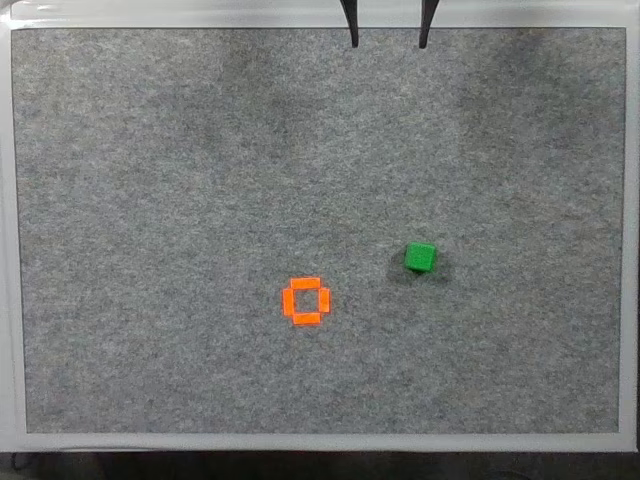

Wrist camera


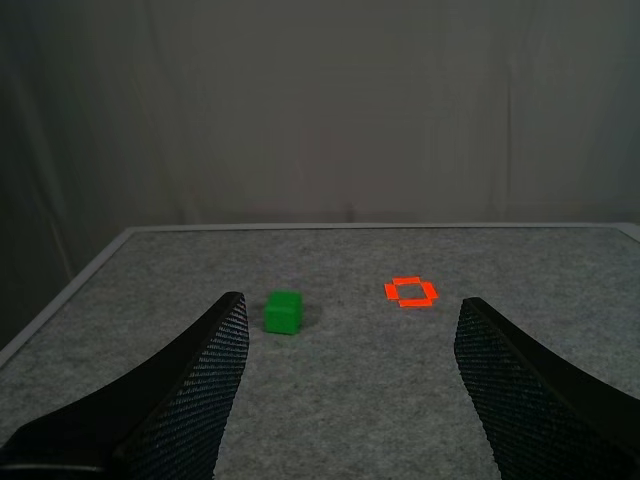

Piper raw dataset check: PASS


In [3]:
from IPython.display import display
from PIL import Image

from piper_vla.training.dataset_v3 import PiperV3Dataset


# ---------------------------------------------------------------------------
# 검증용 dataset 생성
# ---------------------------------------------------------------------------

CHECK_DATASET = PiperV3Dataset(
    root=DATASET_ROOT,
    action_horizon=50,
    validate_samples=True,
)


# ---------------------------------------------------------------------------
# 데이터셋 전체 정보 확인
# ---------------------------------------------------------------------------

DATASET_SUMMARY = CHECK_DATASET.summary()

assert len(CHECK_DATASET) == 201_999
assert CHECK_DATASET.num_episodes == 404
assert CHECK_DATASET.fps == 20

print("Dataset summary")

for key, value in DATASET_SUMMARY.items():
    print(f"  {key:18s}: {value}")


# ---------------------------------------------------------------------------
# 첫 번째 실제 sample 로드
# ---------------------------------------------------------------------------

RAW_SAMPLE = CHECK_DATASET[0]

THIRD_PERSON_IMAGE = RAW_SAMPLE[
    "observation/image"
]

WRIST_IMAGE = RAW_SAMPLE[
    "observation/wrist_image"
]

STATE = RAW_SAMPLE[
    "observation/state"
]

ACTIONS = RAW_SAMPLE[
    "actions"
]

ACTION_IS_PAD = RAW_SAMPLE[
    "action_is_pad"
]

PROMPT = RAW_SAMPLE[
    "prompt"
]


# ---------------------------------------------------------------------------
# Raw sample 계약 검증
# ---------------------------------------------------------------------------

assert THIRD_PERSON_IMAGE.shape == (
    480,
    640,
    3,
)

assert WRIST_IMAGE.shape == (
    480,
    640,
    3,
)

assert THIRD_PERSON_IMAGE.dtype == np.uint8
assert WRIST_IMAGE.dtype == np.uint8

assert STATE.shape == (7,)
assert STATE.dtype == np.float32

assert ACTIONS.shape == (50, 7)
assert ACTIONS.dtype == np.float32

assert ACTION_IS_PAD.shape == (50,)
assert ACTION_IS_PAD.dtype == np.bool_

assert isinstance(PROMPT, str)
assert PROMPT.strip()

assert np.isfinite(STATE).all()
assert np.isfinite(ACTIONS).all()

# zeros 같은 가짜 영상이 아닌 실제 영상인지 확인한다.
assert np.any(THIRD_PERSON_IMAGE)
assert np.any(WRIST_IMAGE)


# ---------------------------------------------------------------------------
# Sample 값 출력
# ---------------------------------------------------------------------------

np.set_printoptions(
    precision=4,
    suppress=True,
)

print()
print("Raw sample")
print("  episode_index :", int(RAW_SAMPLE["episode_index"]))
print("  frame_index   :", int(RAW_SAMPLE["frame_index"]))
print("  timestamp     :", float(RAW_SAMPLE["timestamp"]))
print("  prompt        :", PROMPT)

print()
print("  state         :", STATE)
print("  first action  :", ACTIONS[0])
print("  last action   :", ACTIONS[-1])
print("  padded steps  :", int(ACTION_IS_PAD.sum()))

print()
print(
    "  third-person  :",
    THIRD_PERSON_IMAGE.shape,
    THIRD_PERSON_IMAGE.dtype,
    f"mean={THIRD_PERSON_IMAGE.mean():.4f}",
)

print(
    "  wrist         :",
    WRIST_IMAGE.shape,
    WRIST_IMAGE.dtype,
    f"mean={WRIST_IMAGE.mean():.4f}",
)


# ---------------------------------------------------------------------------
# 실제 카메라 영상 표시
# ---------------------------------------------------------------------------

print()
print("Third-person camera")
display(
    Image.fromarray(
        THIRD_PERSON_IMAGE
    )
)

print("Wrist camera")
display(
    Image.fromarray(
        WRIST_IMAGE
    )
)

print("Piper raw dataset check: PASS")

## 4. 에피소드 경계와 action chunk padding 검증

### 한 문장 요약

**50개 미래 action을 만들 때 다음 episode의 동작이 섞이지 않는지 확인한다.**

π0는 action 하나가 아니라 `action_horizon=50`인 묶음을 예측한다. 데이터가 20Hz이므로 50 step은 약 2.5초다.

```text
현재 frame i
  └─ actions = [i, i+1, ..., i+49]
```

하지만 episode 마지막에서는 `i+49`가 존재하지 않을 수 있다. 이때 adapter는 인덱스를 현재 episode의 마지막 frame에 고정한다.

```text
episode 마지막 frame의 chunk
  실제 마지막 action 1개 + 같은 마지막 action 49회 반복
```

### 코드를 읽는 순서

1. 첫 episode, 중간 episode, 마지막 episode를 고른다.
2. `episode_bounds()`가 주는 `[start, stop)` 범위를 확인한다. `stop`은 포함되지 않는 끝 위치다.
3. `full`, `near`, `last` 세 위치에서 `action_chunk()`를 호출한다.
4. padding 개수와 마지막 action 반복이 예상값 `0`, `1`, `49`인지 검사한다.

### 왜 마지막 action을 반복하는가

zero action을 넣으면 실제 로봇 명령 범위와 다른 갑작스러운 값이 생긴다. 마지막 명령을 유지하면 episode 끝에서 로봇이 마지막 목표를 계속 유지한다는 자연스러운 의미가 된다. 이는 OpenPI가 고정한 기존 LeRobot loader의 동작과도 맞는다.

현재 π0 loss는 `action_is_pad`를 사용해 padded 위치를 제외하지 않는다. 따라서 반복 action은 normalization 통계와 loss 양쪽에 동일하게 포함되어야 한다. 이 동작은 `PiperV3Dataset`의 경계 검사와 숫자 전용 parity 검사로 프로젝트 안에서 직접 검증한다.

### 성공 출력의 의미

세 episode에서 `last=49`가 나오면 action chunk가 episode를 넘어가지 않고 동일한 규칙으로 끝을 처리한다는 뜻이다.


In [4]:
# ---------------------------------------------------------------------------
# 검사할 에피소드 선택
# ---------------------------------------------------------------------------

ACTION_HORIZON = CHECK_DATASET.action_horizon

EPISODES_TO_CHECK = (
    CHECK_DATASET.episode_indices[0],
    CHECK_DATASET.episode_indices[
        len(CHECK_DATASET.episode_indices) // 2
    ],
    CHECK_DATASET.episode_indices[-1],
)


# ---------------------------------------------------------------------------
# 에피소드별 action chunk 경계 검사
# ---------------------------------------------------------------------------

boundary_results = []

for episode_index in EPISODES_TO_CHECK:
    episode_start, episode_stop = (
        CHECK_DATASET.episode_bounds(
            episode_index
        )
    )

    episode_length = (
        episode_stop
        - episode_start
    )

    if episode_length < ACTION_HORIZON:
        raise ValueError(
            f"Episode {episode_index} 길이가 "
            f"action horizon보다 짧습니다: "
            f"{episode_length} < {ACTION_HORIZON}"
        )

    # 정확히 50개의 실제 action이 남은 위치다.
    full_chunk_index = (
        episode_stop
        - ACTION_HORIZON
    )

    full_actions, full_pad = (
        CHECK_DATASET.action_chunk(
            full_chunk_index
        )
    )

    # 마지막 action 하나가 부족한 위치다.
    one_pad_index = (
        full_chunk_index
        + 1
    )

    one_pad_actions, one_pad = (
        CHECK_DATASET.action_chunk(
            one_pad_index
        )
    )

    # 에피소드의 마지막 프레임이다.
    last_frame_index = (
        episode_stop
        - 1
    )

    last_actions, last_pad = (
        CHECK_DATASET.action_chunk(
            last_frame_index
        )
    )


    # -----------------------------------------------------------------------
    # Shape과 padding 개수 검사
    # -----------------------------------------------------------------------

    assert full_actions.shape == (
        ACTION_HORIZON,
        7,
    )

    assert one_pad_actions.shape == (
        ACTION_HORIZON,
        7,
    )

    assert last_actions.shape == (
        ACTION_HORIZON,
        7,
    )

    assert full_pad.dtype == np.bool_
    assert one_pad.dtype == np.bool_
    assert last_pad.dtype == np.bool_

    assert int(full_pad.sum()) == 0
    assert int(one_pad.sum()) == 1
    assert int(last_pad.sum()) == (
        ACTION_HORIZON - 1
    )


    # -----------------------------------------------------------------------
    # 마지막 프레임에서는 마지막 action만 반복되는지 검사
    # -----------------------------------------------------------------------

    repeated_last_action = np.broadcast_to(
        last_actions[0],
        last_actions.shape,
    )

    np.testing.assert_array_equal(
        last_actions,
        repeated_last_action,
    )

    boundary_results.append(
        {
            "episode": episode_index,
            "start": episode_start,
            "stop": episode_stop,
            "length": episode_length,
            "full_pad": int(
                full_pad.sum()
            ),
            "one_pad": int(
                one_pad.sum()
            ),
            "last_pad": int(
                last_pad.sum()
            ),
        }
    )


# ---------------------------------------------------------------------------
# 결과 출력
# ---------------------------------------------------------------------------

print(
    f"{'episode':>8} "
    f"{'start':>8} "
    f"{'stop':>8} "
    f"{'length':>8} "
    f"{'full':>6} "
    f"{'near':>6} "
    f"{'last':>6}"
)

for result in boundary_results:
    print(
        f"{result['episode']:8d} "
        f"{result['start']:8d} "
        f"{result['stop']:8d} "
        f"{result['length']:8d} "
        f"{result['full_pad']:6d} "
        f"{result['one_pad']:6d} "
        f"{result['last_pad']:6d}"
    )

print()
print("Episode boundary check: PASS")

 episode    start     stop   length   full   near   last
       0        0      500      500      0      1     49
     202   100999   101499      500      0      1     49
     403   201499   201999      500      0      1     49

Episode boundary check: PASS


## 5. π0 LoRA 모델 규격과 Piper action 변환

### 한 문장 요약

**Piper의 두 카메라와 7축 absolute action을 π0가 기대하는 이름과 delta 표현으로 바꾼다.**

### 모델 규격

`PI0_LORA_MODEL_CONFIG`는 공식 low-memory π0 설정과 같은 두 LoRA variant를 사용한다.

- PaliGemma 쪽: `gemma_2b_lora`
- action expert 쪽: `gemma_300m_lora`
- action horizon: 50
- 모델 내부 state/action 최대 폭: 32
- prompt 최대 길이: 48 token

이 셀에서는 config만 만들며 base checkpoint는 읽지 않는다.

### 카메라 변환

```text
Piper third-person  → base_0_rgb       (mask=True)
Piper wrist        → left_wrist_0_rgb (mask=True)
없는 right wrist   → 검은 영상         (mask=False)
```

`LiberoInputs`라는 이름은 LIBERO 로봇을 사용한다는 뜻이 아니다. OpenPI에 이미 구현된 **두 카메라 + state/action field 변환 규격**이 Piper와 같아서 재사용하는 것이다.

### action 변환 수식

관절 1~6은 현재 state에서 목표까지의 차이로 바꾼다.

$$a^{delta}_{t+k,j}=a^{absolute}_{t+k,j}-s_{t,j}, \quad j=1,\dots,6$$

gripper는 목표 열림 폭 자체가 의미 있으므로 absolute 값을 유지한다.

$$a^{model}_{t+k,7}=a^{absolute}_{t+k,7}$$

`PIPER_DELTA_MASK = [True, True, True, True, True, True, False]`가 이 규칙을 코드로 표현한다.

### 코드를 읽는 순서

1. 원본 sample을 복사해 변환 전 값을 보존한다.
2. `RepackTransform`으로 학습에 필요한 다섯 key만 선택한다.
3. `LiberoInputs`로 카메라와 state/action 이름을 π0 field로 바꾼다.
4. `DeltaActions`를 깊은 복사본에 적용하고 수식을 직접 계산한 값과 비교한다.

`DeltaActions`는 배열을 제자리에서 수정하므로 `copy.deepcopy()`가 중요하다. 이 검사가 통과하면 dataset 원본은 absolute 값으로 남고, 모델에 들어가는 복사본만 delta로 바뀐다.


In [5]:
# Cell 5 — π0 LoRA 규격과 Piper action 변환 검증

import copy
import numpy as np

from openpi import transforms
from openpi.models import model as model_api
from openpi.models import pi0_config
from openpi.policies import libero_policy


# ------------------------------------------------------------
# 1. 공식 π0 low-memory LoRA 모델 구조
# ------------------------------------------------------------

PI0_LORA_MODEL_CONFIG = pi0_config.Pi0Config(
    paligemma_variant="gemma_2b_lora",
    action_expert_variant="gemma_300m_lora",
)

PI0_LORA_FREEZE_FILTER = PI0_LORA_MODEL_CONFIG.get_freeze_filter()

assert PI0_LORA_MODEL_CONFIG.model_type is model_api.ModelType.PI0
assert PI0_LORA_MODEL_CONFIG.pi05 is False
assert PI0_LORA_MODEL_CONFIG.action_dim == 32
assert PI0_LORA_MODEL_CONFIG.action_horizon == 50
assert PI0_LORA_MODEL_CONFIG.max_token_len == 48
assert PI0_LORA_FREEZE_FILTER is not None


# ------------------------------------------------------------
# 2. 실제 데이터 샘플과 원본 값 보존
# ------------------------------------------------------------

raw_sample = CHECK_DATASET[0]

raw_state = np.asarray(
    raw_sample["observation/state"],
    dtype=np.float32,
).copy()

raw_actions = np.asarray(
    raw_sample["actions"],
    dtype=np.float32,
).copy()


# ------------------------------------------------------------
# 3. 학습에 필요한 키만 선택
# ------------------------------------------------------------

REPACK_TRANSFORM = transforms.RepackTransform(
    {
        "observation/image": "observation/image",
        "observation/wrist_image": "observation/wrist_image",
        "observation/state": "observation/state",
        "actions": "actions",
        "prompt": "prompt",
    }
)

repacked_sample = REPACK_TRANSFORM(raw_sample)

expected_repacked_keys = {
    "observation/image",
    "observation/wrist_image",
    "observation/state",
    "actions",
    "prompt",
}

assert set(repacked_sample) == expected_repacked_keys


# ------------------------------------------------------------
# 4. Piper의 두 카메라를 π0 이미지 슬롯으로 변환
# ------------------------------------------------------------

# Piper의 입력 구조가 공식 LIBERO의 2-camera 계약과 같으므로
# 현재 단계에서는 OpenPI의 검증된 변환을 재사용한다.
ROBOT_INPUT_TRANSFORM = libero_policy.LiberoInputs(
    model_type=PI0_LORA_MODEL_CONFIG.model_type
)

model_ready_7d = ROBOT_INPUT_TRANSFORM(repacked_sample)

expected_image_keys = {
    "base_0_rgb",
    "left_wrist_0_rgb",
    "right_wrist_0_rgb",
}

assert set(model_ready_7d["image"]) == expected_image_keys
assert set(model_ready_7d["image_mask"]) == expected_image_keys

assert model_ready_7d["image"]["base_0_rgb"].shape == (480, 640, 3)
assert model_ready_7d["image"]["left_wrist_0_rgb"].shape == (480, 640, 3)
assert model_ready_7d["image"]["right_wrist_0_rgb"].shape == (480, 640, 3)

assert bool(model_ready_7d["image_mask"]["base_0_rgb"]) is True
assert bool(model_ready_7d["image_mask"]["left_wrist_0_rgb"]) is True
assert bool(model_ready_7d["image_mask"]["right_wrist_0_rgb"]) is False

assert not np.any(model_ready_7d["image"]["right_wrist_0_rgb"])

assert model_ready_7d["state"].shape == (7,)
assert model_ready_7d["actions"].shape == (50, 7)


# ------------------------------------------------------------
# 5. 관절 6축은 delta, gripper는 absolute로 변환
# ------------------------------------------------------------

# True  6개: joint_1~joint_6을 delta action으로 변환
# False 1개: gripper는 absolute action으로 유지
PIPER_DELTA_MASK = transforms.make_bool_mask(6, -1)

expected_delta_mask = np.asarray(
    [True, True, True, True, True, True, False],
    dtype=np.bool_,
)

np.testing.assert_array_equal(
    np.asarray(PIPER_DELTA_MASK, dtype=np.bool_),
    expected_delta_mask,
)

# DeltaActions는 actions 배열을 제자리에서 수정하므로,
# 원본 데이터 보호를 위해 전체 입력을 복사한다.
delta_input = copy.deepcopy(model_ready_7d)

DELTA_ACTION_TRANSFORM = transforms.DeltaActions(
    PIPER_DELTA_MASK
)

delta_ready_7d = DELTA_ACTION_TRANSFORM(delta_input)


# ------------------------------------------------------------
# 6. 수식과 실제 변환 결과 비교
# ------------------------------------------------------------

expected_delta_actions = raw_actions.copy()

expected_delta_actions[:, :6] -= raw_state[None, :6]
# expected_delta_actions[:, 6]은 gripper absolute 값 그대로 유지

np.testing.assert_allclose(
    delta_ready_7d["actions"],
    expected_delta_actions,
    rtol=0.0,
    atol=1e-6,
)

np.testing.assert_allclose(
    delta_ready_7d["actions"][:, 6],
    raw_actions[:, 6],
    rtol=0.0,
    atol=0.0,
)

# 변환 과정에서 dataset 원본이 수정되지 않았는지 검사
np.testing.assert_array_equal(
    np.asarray(raw_sample["observation/state"]),
    raw_state,
)

np.testing.assert_array_equal(
    np.asarray(raw_sample["actions"]),
    raw_actions,
)


# ------------------------------------------------------------
# 7. 결과 출력
# ------------------------------------------------------------

print("π0 model type       :", PI0_LORA_MODEL_CONFIG.model_type)
print("π0 action horizon   :", PI0_LORA_MODEL_CONFIG.action_horizon)
print("π0 model action dim :", PI0_LORA_MODEL_CONFIG.action_dim)
print("Piper delta mask    :", np.asarray(PIPER_DELTA_MASK))
print("Image masks         :", model_ready_7d["image_mask"])

print()
print("Current state       :", np.round(raw_state, 4))
print("Absolute action[0]  :", np.round(raw_actions[0], 4))
print("Converted action[0] :", np.round(delta_ready_7d["actions"][0], 4))

print()
print("PASS: π0 LoRA model configuration")
print("PASS: Piper camera mapping")
print("PASS: 6 joint delta + absolute gripper conversion")

π0 model type       : ModelType.PI0
π0 action horizon   : 50
π0 model action dim : 32
Piper delta mask    : [ True  True  True  True  True  True False]
Image masks         : {'base_0_rgb': True, 'left_wrist_0_rgb': True, 'right_wrist_0_rgb': False}

Current state       : [-0.036   0.0057  0.     -0.0245  0.08    0.0121  0.0603]
Absolute action[0]  : [-0.0358  0.0051  0.0014 -0.0251  0.0801  0.0127  0.085 ]
Converted action[0] : [ 0.0002 -0.0006  0.0014 -0.0005  0.0001  0.0006  0.085 ]

PASS: π0 LoRA model configuration
PASS: Piper camera mapping
PASS: 6 joint delta + absolute gripper conversion


/home/pc/vla_ws/.conda/env/lib/python3.11/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


## 6. 정규화 통계용 숫자 데이터 준비

### 한 문장 요약

**영상 403,998장을 불필요하게 decode하지 않고 Parquet 숫자 열만 빠르게 읽되, 그 결과가 실제 adapter와 같은지 검증한다.**

전체 데이터 201,999 frame에 대해 `dataset[i]`를 호출하면 매번 카메라 두 장을 decode한다. normalization에는 state와 action만 필요하므로, 이 셀은 PyArrow로 숫자 열만 읽는다.

### helper 함수의 역할

| 함수 | 하는 일 |
|---|---|
| `read_parquet_columns()` | 여러 Parquet 파일에서 지정한 열만 읽고 합친다 |
| `scalar_column()` | index 같은 1차원 Arrow 열을 NumPy 배열로 바꾼다 |
| `vector_column()` | state/action list 열을 연속적인 `[N, 7]` float32로 바꾼다 |
| `make_numeric_action_chunk()` | episode 끝을 clamp하며 `[50, 7]` 미래 action을 만든다 |
| `make_numeric_delta_actions()` | 앞 6축만 현재 state를 빼고 gripper는 유지한다 |

### 경계 재구성

episode metadata의 `dataset_from_index`는 시작, `dataset_to_index`는 포함하지 않는 끝이다. 각 frame에 자신이 속한 episode의 stop을 대응시킨 뒤 미래 index를 `stop-1`보다 커지지 않게 제한한다.

### 가장 중요한 parity 검사

빠른 숫자 경로가 틀리면 빠르게 **잘못된 통계**를 만들 뿐이다. 그래서 시작·중간·마지막 index에서 다음을 실제 `PiperV3Dataset`과 비교한다.

1. 현재 7D state
2. episode 경계를 적용한 50×7 absolute action
3. OpenPI `DeltaActions` 결과
4. 숫자 전용 delta 계산 결과

세 위치에서 모두 같아야 다음 통계 셀로 진행한다. 이 셀의 결과 배열은 CPU RAM에 있고 GPU는 사용하지 않는다.


In [6]:
# Cell 6 — 숫자 데이터 로드와 dataset_v3.py 정합성 검증

from pathlib import Path
import copy

import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq


# ------------------------------------------------------------
# 1. 정규화 계산 규격
# ------------------------------------------------------------

ROBOT_DIM = 7
DELTA_JOINT_DIM = 6
NORM_ACTION_HORIZON = PI0_LORA_MODEL_CONFIG.action_horizon

EXPECTED_NUM_FRAMES = 201_999
EXPECTED_NUM_EPISODES = 404

DATA_PARQUET_FILES = sorted(
    (DATASET_ROOT / "data").glob("chunk-*/file-*.parquet")
)

EPISODE_PARQUET_FILES = sorted(
    (DATASET_ROOT / "meta/episodes").glob("chunk-*/file-*.parquet")
)

assert DATA_PARQUET_FILES, (
    f"데이터 Parquet 파일이 없습니다: {DATASET_ROOT / 'data'}"
)

assert EPISODE_PARQUET_FILES, (
    f"에피소드 Parquet 파일이 없습니다: "
    f"{DATASET_ROOT / 'meta/episodes'}"
)


# ------------------------------------------------------------
# 2. 필요한 Parquet 열만 읽는 함수
# ------------------------------------------------------------

def read_parquet_columns(
    files: list[Path],
    columns: list[str],
) -> pa.Table:
    """여러 Parquet 파일에서 지정한 열만 읽어 하나의 Arrow Table로 결합한다."""

    tables: list[pa.Table] = []

    for path in files:
        parquet_file = pq.ParquetFile(path)
        available_columns = set(parquet_file.schema_arrow.names)
        missing_columns = set(columns) - available_columns

        assert not missing_columns, (
            f"{path}: 누락된 열 {sorted(missing_columns)}"
        )

        tables.append(
            parquet_file.read(columns=columns)
        )

    if len(tables) == 1:
        return tables[0]

    return pa.concat_tables(tables)


def scalar_column(
    table: pa.Table,
    name: str,
    dtype,
) -> np.ndarray:
    """Arrow scalar 열을 연속된 NumPy 1차원 배열로 변환한다."""

    column = table.column(name).combine_chunks()

    assert column.null_count == 0, (
        f"{name}: null 값이 있습니다."
    )

    result = np.asarray(
        column.to_numpy(zero_copy_only=False),
        dtype=dtype,
    )

    assert result.shape == (len(column),)

    return np.ascontiguousarray(result)


def vector_column(
    table: pa.Table,
    name: str,
    width: int,
) -> np.ndarray:
    """Arrow list 또는 tensor 열을 float32 [N, width] 배열로 변환한다."""

    column = table.column(name).combine_chunks()

    assert column.null_count == 0, (
        f"{name}: null 값이 있습니다."
    )

    storage = (
        column.storage
        if isinstance(column, pa.ExtensionArray)
        else column
    )

    if pa.types.is_fixed_size_list(storage.type):
        assert storage.type.list_size == width, (
            name,
            storage.type,
        )

        value_start = storage.offset * width
        value_count = len(storage) * width

        values = storage.values.slice(
            value_start,
            value_count,
        )

        result = np.asarray(
            values.to_numpy(zero_copy_only=False),
            dtype=np.float32,
        ).reshape(len(storage), width)

    elif (
        pa.types.is_list(storage.type)
        or pa.types.is_large_list(storage.type)
    ):
        offsets = np.asarray(
            storage.offsets.to_numpy(zero_copy_only=False),
            dtype=np.int64,
        )

        np.testing.assert_array_equal(
            np.diff(offsets),
            np.full(
                len(storage),
                width,
                dtype=np.int64,
            ),
        )

        value_start = int(offsets[0])
        value_count = int(offsets[-1] - offsets[0])

        values = storage.values.slice(
            value_start,
            value_count,
        )

        result = np.asarray(
            values.to_numpy(zero_copy_only=False),
            dtype=np.float32,
        ).reshape(len(storage), width)

    else:
        # 예상하지 못한 Arrow extension 표현에 대한 안전한 fallback
        result = np.asarray(
            storage.to_pylist(),
            dtype=np.float32,
        )

    assert result.shape == (len(column), width), (
        name,
        result.shape,
    )

    assert np.isfinite(result).all(), (
        f"{name}: NaN 또는 Inf가 있습니다."
    )

    return np.ascontiguousarray(
        result,
        dtype=np.float32,
    )


# ------------------------------------------------------------
# 3. 영상 없이 frame 숫자 열만 로드
# ------------------------------------------------------------

frame_table = read_parquet_columns(
    DATA_PARQUET_FILES,
    [
        "index",
        "episode_index",
        "observation.state",
        "action",
    ],
)

FRAME_GLOBAL_INDEX = scalar_column(
    frame_table,
    "index",
    np.int64,
)

FRAME_EPISODE_INDEX = scalar_column(
    frame_table,
    "episode_index",
    np.int64,
)

NUMERIC_STATES = vector_column(
    frame_table,
    "observation.state",
    ROBOT_DIM,
)

NUMERIC_ABSOLUTE_ACTIONS = vector_column(
    frame_table,
    "action",
    ROBOT_DIM,
)


# 여러 Parquet 파일이 있더라도 global index 순서로 정렬
frame_order = np.argsort(
    FRAME_GLOBAL_INDEX,
    kind="stable",
)

FRAME_GLOBAL_INDEX = FRAME_GLOBAL_INDEX[frame_order]
FRAME_EPISODE_INDEX = FRAME_EPISODE_INDEX[frame_order]
NUMERIC_STATES = NUMERIC_STATES[frame_order]
NUMERIC_ABSOLUTE_ACTIONS = NUMERIC_ABSOLUTE_ACTIONS[frame_order]

NUM_FRAMES = len(FRAME_GLOBAL_INDEX)

assert NUM_FRAMES == EXPECTED_NUM_FRAMES, (
    NUM_FRAMES,
    EXPECTED_NUM_FRAMES,
)

np.testing.assert_array_equal(
    FRAME_GLOBAL_INDEX,
    np.arange(NUM_FRAMES, dtype=np.int64),
)


# ------------------------------------------------------------
# 4. 에피소드 시작·끝 위치 로드
# ------------------------------------------------------------

episode_table = read_parquet_columns(
    EPISODE_PARQUET_FILES,
    [
        "episode_index",
        "dataset_from_index",
        "dataset_to_index",
        "length",
    ],
)

EPISODE_IDS = scalar_column(
    episode_table,
    "episode_index",
    np.int64,
)

EPISODE_STARTS = scalar_column(
    episode_table,
    "dataset_from_index",
    np.int64,
)

EPISODE_STOPS = scalar_column(
    episode_table,
    "dataset_to_index",
    np.int64,
)

EPISODE_LENGTHS = scalar_column(
    episode_table,
    "length",
    np.int64,
)


episode_order = np.argsort(
    EPISODE_IDS,
    kind="stable",
)

EPISODE_IDS = EPISODE_IDS[episode_order]
EPISODE_STARTS = EPISODE_STARTS[episode_order]
EPISODE_STOPS = EPISODE_STOPS[episode_order]
EPISODE_LENGTHS = EPISODE_LENGTHS[episode_order]

NUM_EPISODES = len(EPISODE_IDS)

assert NUM_EPISODES == EXPECTED_NUM_EPISODES, (
    NUM_EPISODES,
    EXPECTED_NUM_EPISODES,
)

np.testing.assert_array_equal(
    EPISODE_IDS,
    np.arange(NUM_EPISODES, dtype=np.int64),
)

assert EPISODE_STARTS[0] == 0
assert EPISODE_STOPS[-1] == NUM_FRAMES

np.testing.assert_array_equal(
    EPISODE_STARTS[1:],
    EPISODE_STOPS[:-1],
)

np.testing.assert_array_equal(
    EPISODE_STOPS - EPISODE_STARTS,
    EPISODE_LENGTHS,
)

np.testing.assert_array_equal(
    FRAME_EPISODE_INDEX,
    np.repeat(
        EPISODE_IDS,
        EPISODE_LENGTHS,
    ),
)


# 각 frame이 속한 episode의 exclusive stop index
EPISODE_STOP_FOR_FRAME = np.repeat(
    EPISODE_STOPS,
    EPISODE_LENGTHS,
)

assert EPISODE_STOP_FOR_FRAME.shape == (NUM_FRAMES,)


# ------------------------------------------------------------
# 5. 숫자 배열에서 action chunk를 만드는 함수
# ------------------------------------------------------------

def make_numeric_action_chunk(
    global_index: int,
) -> np.ndarray:
    """dataset_v3.py와 동일하게 episode 끝에서 마지막 action을 반복한다."""

    episode_stop = int(
        EPISODE_STOP_FOR_FRAME[global_index]
    )

    future_indices = (
        global_index
        + np.arange(
            NORM_ACTION_HORIZON,
            dtype=np.int64,
        )
    )

    future_indices = np.minimum(
        future_indices,
        episode_stop - 1,
    )

    return NUMERIC_ABSOLUTE_ACTIONS[
        future_indices
    ].copy()


def make_numeric_delta_actions(
    global_index: int,
) -> np.ndarray:
    """관절 6축은 delta, gripper는 absolute로 변환한다."""

    action_chunk = make_numeric_action_chunk(
        global_index
    )

    action_chunk[:, :DELTA_JOINT_DIM] -= (
        NUMERIC_STATES[
            global_index,
            None,
            :DELTA_JOINT_DIM,
        ]
    )

    return action_chunk


# ------------------------------------------------------------
# 6. 실제 adapter와 숫자 전용 경로 비교
# ------------------------------------------------------------

PARITY_CHECK_INDICES = (
    0,
    NUM_FRAMES // 2,
    NUM_FRAMES - 1,
)

for sample_index in PARITY_CHECK_INDICES:
    adapter_sample = CHECK_DATASET[sample_index]

    # raw state 비교
    np.testing.assert_allclose(
        adapter_sample["observation/state"],
        NUMERIC_STATES[sample_index],
        rtol=0.0,
        atol=1e-6,
    )

    # episode boundary가 적용된 absolute action chunk 비교
    expected_absolute_chunk = make_numeric_action_chunk(
        sample_index
    )

    np.testing.assert_allclose(
        adapter_sample["actions"],
        expected_absolute_chunk,
        rtol=0.0,
        atol=1e-6,
    )

    # 실제 OpenPI transform 경로 적용
    transformed_sample = DELTA_ACTION_TRANSFORM(
        copy.deepcopy(
            ROBOT_INPUT_TRANSFORM(
                REPACK_TRANSFORM(adapter_sample)
            )
        )
    )

    # 숫자 전용 delta 계산과 OpenPI transform 결과 비교
    expected_delta_chunk = make_numeric_delta_actions(
        sample_index
    )

    np.testing.assert_allclose(
        transformed_sample["actions"],
        expected_delta_chunk,
        rtol=0.0,
        atol=1e-6,
    )

    print(
        f"index={sample_index:6d}",
        f"episode={int(FRAME_EPISODE_INDEX[sample_index]):3d}",
        f"episode_stop={int(EPISODE_STOP_FOR_FRAME[sample_index]):6d}",
        "PASS",
    )


# ------------------------------------------------------------
# 7. 결과 출력
# ------------------------------------------------------------

print()
print("Frames loaded       :", f"{NUM_FRAMES:,}")
print("Episodes loaded     :", f"{NUM_EPISODES:,}")
print("State array         :", NUMERIC_STATES.shape, NUMERIC_STATES.dtype)
print(
    "Absolute actions    :",
    NUMERIC_ABSOLUTE_ACTIONS.shape,
    NUMERIC_ABSOLUTE_ACTIONS.dtype,
)

print()
print("PASS: numeric Parquet loading")
print("PASS: episode boundary reconstruction")
print("PASS: dataset_v3.py and numeric path parity")

index=     0 episode=  0 episode_stop=   500 PASS
index=100999 episode=202 episode_stop=101499 PASS
index=201998 episode=403 episode_stop=201999 PASS

Frames loaded       : 201,999
Episodes loaded     : 404
State array         : (201999, 7) float32
Absolute actions    : (201999, 7) float32

PASS: numeric Parquet loading
PASS: episode boundary reconstruction
PASS: dataset_v3.py and numeric path parity


## 7. 전체 데이터셋의 π0 normalization stats 계산

### 한 문장 요약

**각 축의 평균과 표준편차를 계산해 큰 값과 작은 값이 학습에서 비슷한 비중을 갖게 만든다.**

### π0에서 사용하는 z-score

π0는 다음 수식으로 state와 action을 바꾼다.

$$x_{norm}=\frac{x-\mu}{\sigma+10^{-6}}$$

여기서 $\mu$는 평균, $\sigma$는 표준편차다. 예를 들어 joint 2의 범위가 gripper보다 훨씬 커도 정규화 후에는 두 축이 optimizer에 비슷한 크기의 신호를 제공한다.

### 통계에 들어가는 값

- state: 각 frame의 raw absolute 7D state, 총 201,999개
- action joint 1~6: 미래 absolute action에서 현재 state를 뺀 delta
- action gripper: absolute 값 유지
- 각 frame마다 미래 50개를 모두 사용: 총 10,099,950개 action vector

통계는 모델의 32D padding **이전**에 계산한다. 뒤의 25개 0까지 통계에 넣으면 실제 로봇 7축의 평균과 표준편차가 왜곡된다.

### `compute_pi0_norm_stats()` 읽는 순서

1. `RunningStats`를 state와 actions 각각 새로 만든다.
2. frame 4,096개 단위로 현재 state와 future action chunk를 만든다.
3. 6개 joint를 delta로 바꾼 뒤 `update()`한다.
4. 모든 batch가 끝나면 `mean`, `std`, `q01`, `q99`를 꺼낸다.

`RunningStats`는 모든 1천만 action을 한 번에 RAM에 저장하지 않는다. 작은 batch를 계속 누적해 평균·분산과 histogram 기반 분위수를 계산한다.

π0 학습은 `mean/std`를 사용한다. `q01/q99`도 함께 저장하는 이유는 OpenPI의 표준 `NormStats` 형식을 유지하고 이후 다른 정책과 비교하기 위해서다.


In [7]:
# Cell 7 — 전체 π0 normalization stats 계산

import time

import numpy as np
from tqdm.auto import tqdm

from openpi.shared import normalize


# ------------------------------------------------------------
# 1. 통계 계산 설정
# ------------------------------------------------------------

STATS_BATCH_FRAMES = 4096

EXPECTED_STATE_VECTOR_COUNT = NUM_FRAMES
EXPECTED_ACTION_VECTOR_COUNT = (
    NUM_FRAMES * NORM_ACTION_HORIZON
)

PIPER_FEATURE_NAMES = (
    "joint_1",
    "joint_2",
    "joint_3",
    "joint_4",
    "joint_5",
    "joint_6",
    "gripper",
)


# ------------------------------------------------------------
# 2. 전체 통계 계산 함수
# ------------------------------------------------------------

def compute_pi0_norm_stats():
    """
    전체 LeRobot v3 숫자 데이터에서 π0용 통계를 계산한다.

    함수 내부에서 RunningStats를 새로 생성하므로
    노트북 셀을 재실행해도 이전 결과가 중복 누적되지 않는다.
    """

    state_running = normalize.RunningStats()
    action_running = normalize.RunningStats()

    horizon_offsets = np.arange(
        NORM_ACTION_HORIZON,
        dtype=np.int64,
    )[None, :]

    state_vector_count = 0
    action_vector_count = 0

    started_at = time.perf_counter()

    with tqdm(
        total=NUM_FRAMES,
        desc="Computing π0 norm stats",
        unit="frame",
        mininterval=0.5,
    ) as progress:
        for begin in range(
            0,
            NUM_FRAMES,
            STATS_BATCH_FRAMES,
        ):
            end = min(
                begin + STATS_BATCH_FRAMES,
                NUM_FRAMES,
            )

            current_indices = np.arange(
                begin,
                end,
                dtype=np.int64,
            )

            # --------------------------------------------
            # state: 각 frame의 raw 7D state
            # --------------------------------------------

            current_states = NUMERIC_STATES[
                current_indices
            ]

            state_running.update(current_states)

            # --------------------------------------------
            # action: episode 경계를 적용한 [B, 50, 7]
            # --------------------------------------------

            future_indices = (
                current_indices[:, None]
                + horizon_offsets
            )

            episode_last_indices = (
                EPISODE_STOP_FOR_FRAME[
                    current_indices,
                    None,
                ]
                - 1
            )

            future_indices = np.minimum(
                future_indices,
                episode_last_indices,
            )

            action_chunks = (
                NUMERIC_ABSOLUTE_ACTIONS[
                    future_indices
                ].copy()
            )

            # joint 1~6:
            # future absolute action - current state
            action_chunks[
                ...,
                :DELTA_JOINT_DIM,
            ] -= current_states[
                :,
                None,
                :DELTA_JOINT_DIM,
            ]

            # gripper 차원은 absolute 값 그대로 유지
            action_running.update(action_chunks)

            batch_frame_count = end - begin

            state_vector_count += batch_frame_count
            action_vector_count += (
                batch_frame_count
                * NORM_ACTION_HORIZON
            )

            progress.update(batch_frame_count)

    norm_stats = {
        "state": state_running.get_statistics(),
        "actions": action_running.get_statistics(),
    }

    elapsed_seconds = (
        time.perf_counter() - started_at
    )

    counts = {
        "state": state_vector_count,
        "actions": action_vector_count,
    }

    return norm_stats, counts, elapsed_seconds


# 셀을 재실행할 때마다 새로운 통계를 처음부터 계산
PI0_NORM_STATS, NORM_STATS_COUNTS, NORM_STATS_ELAPSED = (
    compute_pi0_norm_stats()
)


# ------------------------------------------------------------
# 3. 통계 개수 검증
# ------------------------------------------------------------

assert (
    NORM_STATS_COUNTS["state"]
    == EXPECTED_STATE_VECTOR_COUNT
)

assert (
    NORM_STATS_COUNTS["actions"]
    == EXPECTED_ACTION_VECTOR_COUNT
)


# ------------------------------------------------------------
# 4. OpenPI NormStats 구조 검증
# ------------------------------------------------------------

for stats_key in ("state", "actions"):
    stats = PI0_NORM_STATS[stats_key]

    assert stats.mean.shape == (ROBOT_DIM,)
    assert stats.std.shape == (ROBOT_DIM,)
    assert stats.q01.shape == (ROBOT_DIM,)
    assert stats.q99.shape == (ROBOT_DIM,)

    assert np.isfinite(stats.mean).all()
    assert np.isfinite(stats.std).all()
    assert np.isfinite(stats.q01).all()
    assert np.isfinite(stats.q99).all()

    assert np.all(stats.std >= 0.0)
    assert np.all(stats.q01 <= stats.q99)


# ------------------------------------------------------------
# 5. 결과 출력
# ------------------------------------------------------------

state_stats = PI0_NORM_STATS["state"]
action_stats = PI0_NORM_STATS["actions"]

print()
print(
    "State vectors counted :",
    f"{NORM_STATS_COUNTS['state']:,}",
)

print(
    "Action vectors counted:",
    f"{NORM_STATS_COUNTS['actions']:,}",
)

print(
    "Elapsed               :",
    f"{NORM_STATS_ELAPSED:.1f} seconds",
)

print()
print(
    f"{'feature':<10}"
    f"{'state mean':>13}"
    f"{'state std':>13}"
    f"{'action mean':>14}"
    f"{'action std':>13}"
    f"{'action q01':>13}"
    f"{'action q99':>13}"
)

for feature_index, feature_name in enumerate(
    PIPER_FEATURE_NAMES
):
    print(
        f"{feature_name:<10}"
        f"{state_stats.mean[feature_index]:>13.6f}"
        f"{state_stats.std[feature_index]:>13.6f}"
        f"{action_stats.mean[feature_index]:>14.6f}"
        f"{action_stats.std[feature_index]:>13.6f}"
        f"{action_stats.q01[feature_index]:>13.6f}"
        f"{action_stats.q99[feature_index]:>13.6f}"
    )

print()
print("PASS: complete dataset normalization stats")
print("PASS: 7D state stats before model padding")
print("PASS: 6 joint delta + absolute gripper action stats")

Computing π0 norm stats: 100%|██████████| 201999/201999 [00:01<00:00, 110278.61frame/s]


State vectors counted : 201,999
Action vectors counted: 10,099,950
Elapsed               : 1.8 seconds

feature      state mean    state std   action mean   action std   action q01   action q99
joint_1       -0.097872     0.228911     -0.000008     0.108764    -0.440774     0.296211
joint_2        1.214297     0.936531     -0.003735     0.477437    -1.692345     1.159606
joint_3       -0.982049     0.781018      0.002872     0.399767    -0.961100     1.498058
joint_4        0.049607     0.141835      0.000294     0.090592    -0.290813     0.309024
joint_5        0.580920     0.440872     -0.000850     0.259113    -1.019638     0.804058
joint_6       -0.172849     0.293390     -0.000175     0.158703    -0.592563     0.481210
gripper        0.050480     0.015551      0.053801     0.028223     0.000170     0.084983

PASS: complete dataset normalization stats
PASS: 7D state stats before model padding
PASS: 6 joint delta + absolute gripper action stats


## 8. π0 normalization stats 저장과 재로드

### 한 문장 요약

**방금 계산한 통계를 dataset 공용 asset으로 저장하고, 디스크에서 다시 읽어 수치가 그대로인지 확인한다.**

### asset과 run의 차이

```text
data/assets/...  = 같은 dataset/transform을 쓰는 여러 run이 공유하는 입력 규칙
data/runs/...    = 특정 실험의 step, optimizer, checkpoint 결과
```

현재 통계는 다음 경로에 저장된다.

```text
data/assets/pi0_piper_lora/background_400_0818_v3/norm_stats.json
```

### 코드를 읽는 순서

1. `PI0_NORM_STATS_DIR`와 최종 JSON 경로를 계산한다.
2. `assert_norm_stats_equal()`이 mean/std/q01/q99 네 항목을 비교한다.
3. 파일이 없으면 `normalize.save()`로 새로 저장한다.
4. 파일이 이미 있으면 현재 계산값과 정확히 같은 경우에만 재사용한다.
5. `normalize.load()`로 다시 읽고 shape와 수치를 재검증한다.

자동 overwrite를 하지 않는 이유는 데이터나 delta 규칙이 바뀌었는데 옛 통계를 조용히 사용하는 사고를 막기 위해서다.

### 언제 다시 계산해야 하는가

dataset frame이 바뀌거나, action 단위·축 순서·absolute/delta 규칙·horizon이 바뀌면 새 asset ID를 사용해 통계를 다시 계산한다. 이 파일은 이후 checkpoint의 `assets/<asset_id>/norm_stats.json`에도 복사되어 추론이 학습과 같은 역정규화를 사용하게 한다.


In [8]:
# Cell 8 — OpenPI normalization asset 저장과 재로드

from pathlib import Path

import numpy as np

from openpi.shared import normalize


# ------------------------------------------------------------
# 1. OpenPI asset 경로 정의
# ------------------------------------------------------------

PI0_TRAIN_CONFIG_NAME = "pi0_piper_lora"
PIPER_ASSET_ID = "background_400_0818_v3"

PI0_ASSETS_BASE_DIR = (
    WORKSPACE_ROOT
    / "data"
    / "assets"
)

PI0_NORM_STATS_DIR = (
    PI0_ASSETS_BASE_DIR
    / PI0_TRAIN_CONFIG_NAME
    / PIPER_ASSET_ID
)

PI0_NORM_STATS_FILE = (
    PI0_NORM_STATS_DIR
    / "norm_stats.json"
)


# ------------------------------------------------------------
# 2. 두 NormStats 결과가 같은지 비교
# ------------------------------------------------------------

def assert_norm_stats_equal(
    expected: dict,
    actual: dict,
) -> None:
    assert set(expected) == {"state", "actions"}
    assert set(actual) == {"state", "actions"}

    for stats_key in ("state", "actions"):
        expected_stats = expected[stats_key]
        actual_stats = actual[stats_key]

        for field_name in (
            "mean",
            "std",
            "q01",
            "q99",
        ):
            expected_value = np.asarray(
                getattr(expected_stats, field_name)
            )

            actual_value = np.asarray(
                getattr(actual_stats, field_name)
            )

            assert expected_value.shape == (ROBOT_DIM,)
            assert actual_value.shape == (ROBOT_DIM,)

            np.testing.assert_allclose(
                actual_value,
                expected_value,
                rtol=1e-12,
                atol=1e-12,
            )


# ------------------------------------------------------------
# 3. 신규 저장 또는 기존 동일 파일 재사용
# ------------------------------------------------------------

if PI0_NORM_STATS_FILE.exists():
    existing_norm_stats = normalize.load(
        PI0_NORM_STATS_DIR
    )

    try:
        assert_norm_stats_equal(
            PI0_NORM_STATS,
            existing_norm_stats,
        )
    except AssertionError as error:
        raise RuntimeError(
            "기존 norm_stats.json이 현재 계산 결과와 다릅니다.\n"
            f"기존 파일: {PI0_NORM_STATS_FILE}\n"
            "dataset이나 action transform이 변경됐는지 먼저 확인하세요. "
            "이 셀은 기존 파일을 자동으로 덮어쓰지 않습니다."
        ) from error

    print("Existing identical asset: reused")

else:
    normalize.save(
        PI0_NORM_STATS_DIR,
        PI0_NORM_STATS,
    )

    print("New normalization asset: saved")


# ------------------------------------------------------------
# 4. 디스크에서 다시 로드하여 검증
# ------------------------------------------------------------

LOADED_PI0_NORM_STATS = normalize.load(
    PI0_NORM_STATS_DIR
)

assert PI0_NORM_STATS_FILE.is_file()

assert_norm_stats_equal(
    PI0_NORM_STATS,
    LOADED_PI0_NORM_STATS,
)


# ------------------------------------------------------------
# 5. 결과 출력
# ------------------------------------------------------------

print("Asset directory :", PI0_NORM_STATS_DIR)
print("Stats file      :", PI0_NORM_STATS_FILE)
print(
    "File size       :",
    f"{PI0_NORM_STATS_FILE.stat().st_size:,} bytes",
)

print(
    "Loaded keys     :",
    sorted(LOADED_PI0_NORM_STATS),
)

print(
    "State shape     :",
    LOADED_PI0_NORM_STATS["state"].mean.shape,
)

print(
    "Actions shape   :",
    LOADED_PI0_NORM_STATS["actions"].mean.shape,
)

print()
print("PASS: OpenPI normalization asset saved")
print("PASS: disk reload matches computed stats")

Existing identical asset: reused
Asset directory : /home/pc/vla_ws/data/assets/pi0_piper_lora/background_400_0818_v3
Stats file      : /home/pc/vla_ws/data/assets/pi0_piper_lora/background_400_0818_v3/norm_stats.json
File size       : 1,886 bytes
Loaded keys     : ['actions', 'state']
State shape     : (7,)
Actions shape   : (7,)

PASS: OpenPI normalization asset saved
PASS: disk reload matches computed stats


## 9. OpenPI 전처리 파이프라인과 JAX 학습 배치 생성

### 한 문장 요약

**raw Piper sample 하나가 실제 π0 Observation과 50×32 action target으로 바뀌는 전체 전처리를 한 번에 검증한다.**

### 변환 순서

```text
raw sample
  → Repack: 필요한 key만 남김
  → LiberoInputs: Piper field를 π0 image/state/actions로 배치
  → DeltaActions: joint 6축만 absolute→delta
  → Normalize: 저장한 7D mean/std 적용
  → ResizeImages: 480×640→224×224
  → TokenizePrompt: 문장→최대 48 token
  → PadStatesAndActions: 7D→32D
  → Observation.from_dict: JAX batch와 [-1, 1] 이미지 생성
```

순서가 중요하다. normalization은 7D 통계가 있으므로 padding 전에 적용하고, 뒤의 25개 0은 정규화하지 않는다.

### 최종 batch

| 값 | shape | 알아둘 점 |
|---|---:|---|
| 각 image | `(B, 224, 224, 3)` | uint8가 float32 `[-1,1]`로 바뀜 |
| image mask | `(B,)` | base/left는 True, 없는 right는 False |
| state | `(B, 32)` | 앞 7개만 유효, 뒤 25개는 0 |
| actions | `(B, 50, 32)` | 앞 7개만 유효, 뒤 25개는 0 |
| prompt token | `(B, 48)` | token ID와 유효 위치 mask |

state/action의 z-score 값은 `[-1,1]`로 제한되지 않는다. `[-1,1]` 범위 검사는 RGB 이미지에만 적용한다.

### 학습과 추론이 공유하는 역변환

`PIPER_DATA_CONFIG.data_transforms.outputs`에는 추론용 반대 방향도 들어 있다.

```text
model normalized delta
  → unnormalize
  → AbsoluteActions: current state를 joint 1~6에 다시 더함
  → LiberoOutputs: 실제 Piper 7D action만 반환
```

첫 sample을 손으로 계산한 z-score와 JAX batch 앞 7개가 같고, 나머지 25개가 모두 0이면 전체 파이프라인이 맞다.

> **학습 시 추가 변환:** 이 셀의 DataLoader 출력은 아직 최종 train augmentation 전이다. 실제 `train_step` 안에서 observation을 `train=True`로 전처리하며 외부 카메라 crop/resize/작은 회전과 카메라 color jitter가 적용된다. 따라서 학습 중 모델이 보는 영상은 이 셀에 표시된 영상과 픽셀 단위로 완전히 같지 않다.


In [9]:
# Cell 9 — OpenPI 전처리 파이프라인과 JAX batch 검증

import numpy as np
import jax
import jax.numpy as jnp

from openpi import transforms
from openpi.models import model as model_api
from openpi.policies import libero_policy
from openpi.training import config as training_config
from openpi.training import data_loader


# ------------------------------------------------------------
# 1. 추론 시 사용할 action 역변환도 함께 정의
# ------------------------------------------------------------

# 학습 입력:
# absolute joint action -> delta joint action
#
# 추론 출력:
# delta joint action -> absolute joint action
ABSOLUTE_ACTION_TRANSFORM = transforms.AbsoluteActions(
    PIPER_DELTA_MASK
)

ROBOT_OUTPUT_TRANSFORM = libero_policy.LiberoOutputs()


# ------------------------------------------------------------
# 2. π0 모델 전용 transform
# ------------------------------------------------------------

# 내부 순서:
# - default prompt 처리
# - 이미지 224×224 resize
# - prompt 48 token 변환
# - state/action 7D -> 32D zero padding
PI0_MODEL_TRANSFORMS = (
    training_config.ModelTransformFactory()(
        PI0_LORA_MODEL_CONFIG
    )
)


# ------------------------------------------------------------
# 3. Piper용 OpenPI DataConfig
# ------------------------------------------------------------

PIPER_DATA_CONFIG = training_config.DataConfig(
    # stock LeRobot v2.1 loader를 호출하지 않으므로
    # 여기서는 dataset과 checkpoint asset 식별자로 사용한다.
    repo_id=PIPER_ASSET_ID,
    asset_id=PIPER_ASSET_ID,

    norm_stats=LOADED_PI0_NORM_STATS,

    # canonical 키만 남기고 episode_index 등의 debug metadata 제거
    repack_transforms=transforms.Group(
        inputs=(REPACK_TRANSFORM,),
    ),

    # 학습 입력 변환과 추론 출력 역변환
    data_transforms=transforms.Group(
        inputs=(
            ROBOT_INPUT_TRANSFORM,
            DELTA_ACTION_TRANSFORM,
        ),
        outputs=(
            ABSOLUTE_ACTION_TRANSFORM,
            ROBOT_OUTPUT_TRANSFORM,
        ),
    ),

    model_transforms=PI0_MODEL_TRANSFORMS,

    # π0는 mean/std 기반 z-score normalization 사용
    use_quantile_norm=False,

    action_sequence_keys=("actions",),

    # prompt는 dataset_v3.py가 직접 제공
    prompt_from_task=False,
)


assert PIPER_DATA_CONFIG.repo_id == PIPER_ASSET_ID
assert PIPER_DATA_CONFIG.asset_id == PIPER_ASSET_ID
assert PIPER_DATA_CONFIG.use_quantile_norm is False
assert PIPER_DATA_CONFIG.prompt_from_task is False


# ------------------------------------------------------------
# 4. 실제 transform이 적용되는 dataset 생성
# ------------------------------------------------------------

PI0_TRANSFORMED_DATASET = data_loader.transform_dataset(
    CHECK_DATASET,
    PIPER_DATA_CONFIG,
    skip_norm_stats=False,
)


# ------------------------------------------------------------
# 5. JAX batch 1개 생성
# ------------------------------------------------------------

# 여기서는 전처리 계약을 확인하기 위해:
# - batch size 1
# - 순서 고정
# - worker 0
# - batch 1개
PI0_BATCH_LOADER = data_loader.TorchDataLoader(
    PI0_TRANSFORMED_DATASET,
    local_batch_size=1,
    shuffle=False,
    num_batches=1,
    num_workers=0,
    seed=42,
    framework="jax",
)

# DataLoaderImpl이 dict batch를 공식 Observation으로 변환한다.
PI0_JAX_LOADER = data_loader.DataLoaderImpl(
    PIPER_DATA_CONFIG,
    PI0_BATCH_LOADER,
)

observation, actions = next(
    iter(PI0_JAX_LOADER)
)


# ------------------------------------------------------------
# 6. Observation 타입과 카메라 검증
# ------------------------------------------------------------

assert isinstance(
    observation,
    model_api.Observation,
)

assert isinstance(actions, jax.Array)

assert set(observation.images) == set(
    model_api.IMAGE_KEYS
)

assert set(observation.image_masks) == set(
    model_api.IMAGE_KEYS
)

for image_key in model_api.IMAGE_KEYS:
    image = observation.images[image_key]
    image_mask = observation.image_masks[image_key]

    assert isinstance(image, jax.Array)
    assert isinstance(image_mask, jax.Array)

    assert image.shape == (1, 224, 224, 3), (
        image_key,
        image.shape,
    )

    assert image.dtype == jnp.float32

    assert image_mask.shape == (1,)
    assert image_mask.dtype == jnp.bool_

    image_numpy = np.asarray(image)

    assert np.isfinite(image_numpy).all()
    assert image_numpy.min() >= -1.00001
    assert image_numpy.max() <= 1.00001


assert bool(
    observation.image_masks["base_0_rgb"][0]
) is True

assert bool(
    observation.image_masks["left_wrist_0_rgb"][0]
) is True

assert bool(
    observation.image_masks["right_wrist_0_rgb"][0]
) is False


# ------------------------------------------------------------
# 7. state와 action shape 검증
# ------------------------------------------------------------

assert observation.state.shape == (
    1,
    PI0_LORA_MODEL_CONFIG.action_dim,
)

assert observation.state.shape == (1, 32)
assert observation.state.dtype == jnp.float32

assert actions.shape == (
    1,
    PI0_LORA_MODEL_CONFIG.action_horizon,
    PI0_LORA_MODEL_CONFIG.action_dim,
)

assert actions.shape == (1, 50, 32)
assert actions.dtype == jnp.float32

assert np.isfinite(
    np.asarray(observation.state)
).all()

assert np.isfinite(
    np.asarray(actions)
).all()


# ------------------------------------------------------------
# 8. prompt token 검증
# ------------------------------------------------------------

assert observation.tokenized_prompt is not None
assert observation.tokenized_prompt_mask is not None

assert observation.tokenized_prompt.shape == (
    1,
    PI0_LORA_MODEL_CONFIG.max_token_len,
)

assert observation.tokenized_prompt.shape == (1, 48)
assert observation.tokenized_prompt.dtype == jnp.int32

assert observation.tokenized_prompt_mask.shape == (
    1,
    48,
)

assert (
    observation.tokenized_prompt_mask.dtype
    == jnp.bool_
)

assert bool(
    jnp.any(
        observation.tokenized_prompt_mask[0]
    )
)


# ------------------------------------------------------------
# 9. 7D 이후 zero padding 검증
# ------------------------------------------------------------

np.testing.assert_array_equal(
    np.asarray(
        observation.state[0, ROBOT_DIM:]
    ),
    np.zeros(
        PI0_LORA_MODEL_CONFIG.action_dim - ROBOT_DIM,
        dtype=np.float32,
    ),
)

np.testing.assert_array_equal(
    np.asarray(
        actions[0, :, ROBOT_DIM:]
    ),
    np.zeros(
        (
            PI0_LORA_MODEL_CONFIG.action_horizon,
            PI0_LORA_MODEL_CONFIG.action_dim - ROBOT_DIM,
        ),
        dtype=np.float32,
    ),
)


# ------------------------------------------------------------
# 10. 첫 sample의 normalization 수치 직접 검증
# ------------------------------------------------------------

raw_first_sample = CHECK_DATASET[0]

raw_first_state = np.asarray(
    raw_first_sample["observation/state"],
    dtype=np.float32,
)

expected_actions_7d = np.asarray(
    raw_first_sample["actions"],
    dtype=np.float32,
).copy()

expected_actions_7d[
    ...,
    :DELTA_JOINT_DIM,
] -= raw_first_state[
    None,
    :DELTA_JOINT_DIM,
]

state_stats = LOADED_PI0_NORM_STATS["state"]
action_stats = LOADED_PI0_NORM_STATS["actions"]

expected_state_7d = (
    raw_first_state
    - np.asarray(state_stats.mean)
) / (
    np.asarray(state_stats.std)
    + 1e-6
)

expected_actions_7d = (
    expected_actions_7d
    - np.asarray(action_stats.mean)
) / (
    np.asarray(action_stats.std)
    + 1e-6
)

np.testing.assert_allclose(
    np.asarray(
        observation.state[0, :ROBOT_DIM]
    ),
    expected_state_7d,
    rtol=1e-5,
    atol=1e-5,
)

np.testing.assert_allclose(
    np.asarray(
        actions[0, :, :ROBOT_DIM]
    ),
    expected_actions_7d,
    rtol=1e-5,
    atol=1e-5,
)


# ------------------------------------------------------------
# 11. 결과 출력
# ------------------------------------------------------------

print(
    "State batch       :",
    observation.state.shape,
    observation.state.dtype,
)

print(
    "Action batch      :",
    actions.shape,
    actions.dtype,
)

print(
    "Prompt tokens     :",
    observation.tokenized_prompt.shape,
    observation.tokenized_prompt.dtype,
)

print(
    "Image masks       :",
    {
        key: bool(
            observation.image_masks[key][0]
        )
        for key in model_api.IMAGE_KEYS
    },
)

print(
    "Image ranges      :",
    {
        key: (
            round(
                float(
                    jnp.min(
                        observation.images[key]
                    )
                ),
                4,
            ),
            round(
                float(
                    jnp.max(
                        observation.images[key]
                    )
                ),
                4,
            ),
        )
        for key in model_api.IMAGE_KEYS
    },
)

print(
    "Normalized state  :",
    np.round(
        np.asarray(
            observation.state[0, :ROBOT_DIM]
        ),
        4,
    ),
)

print()
print("PASS: OpenPI Piper DataConfig")
print("PASS: complete JAX preprocessing pipeline")
print("PASS: normalized and padded π0 training batch")

/home/pc/vla_ws/.conda/env/lib/python3.11/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/home/pc/vla_ws/.conda/env/lib/python3.11/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


State batch       : (1, 32) float32
Action batch      : (1, 50, 32) float32
Prompt tokens     : (1, 48) int32
Image masks       : {'base_0_rgb': True, 'left_wrist_0_rgb': True, 'right_wrist_0_rgb': False}
Image ranges      : {'base_0_rgb': (-1.0, 1.0), 'left_wrist_0_rgb': (-1.0, 0.9294), 'right_wrist_0_rgb': (-1.0, -1.0)}
Normalized state  : [ 0.2705 -1.2905  1.2574 -0.5228 -1.1361  0.6304  0.6295]

PASS: OpenPI Piper DataConfig
PASS: complete JAX preprocessing pipeline
PASS: normalized and padded π0 training batch


## 10. 공식 π0 LoRA 기반 Piper TrainConfig 구성

### 한 문장 요약

**공식 모델·LoRA freeze filter·optimizer·learning-rate schedule·EMA 설정은 유지하고, Piper 데이터 규칙과 실행 옵션을 교체한다.**

### 왜 공식 config를 출발점으로 쓰는가

학습률, optimizer, freeze filter, 모델 variant를 임의로 다시 만들면 공식 checkpoint와 작은 차이가 생길 수 있다. `get_config("pi0_libero_low_mem_finetune")`에서 검증된 값을 가져오고 `dataclasses.replace()`로 필요한 항목만 바꾼다.

### `PiperDataConfigFactory.create()`의 역할

1. `assets_dirs / asset_id / norm_stats.json`을 읽는다.
2. 이미 canonical key를 내는 `PiperV3Dataset`용 Repack을 만든다.
3. 입력에는 `LiberoInputs → DeltaActions`를 연결한다.
4. 출력에는 `AbsoluteActions → LiberoOutputs`를 연결한다.
5. π0 전용 resize/tokenize/padding transform을 붙인다.

Factory는 dataset을 읽는 객체가 아니라 **학습과 추론이 따라야 할 변환 규칙을 만드는 설계도**다.

### TrainConfig에서 고정하는 것

| 항목 | 현재 값 | 의미 |
|---|---|---|
| `name` | `pi0_piper_lora` | asset/checkpoint 상위 이름 |
| `exp_name` | dataset별 run 이름 | 하나의 실험 폴더 |
| `weight_loader` | local `pi0_base/params` | fresh 초기화에서만 사용 |
| `batch_size` | 1 | 첫 GPU 검증의 안전한 시작값 |
| `ema_decay` | `None` | 공식 LoRA 설정과 동일 |
| `overwrite/resume` | 둘 다 False | 기존 run을 자동 삭제하거나 복원하지 않음 |

이 셀은 tokenizer transform과 작은 JSON asset은 읽을 수 있지만 12GB 모델 파라미터는 읽지 않는다. `checkpoint_dir`이 이미 있다면 자동 overwrite 대신 새 run 이름 또는 명시적 resume를 사용한다.

> **현재 production과의 관계:** 이 셀의 `PiperDataConfigFactory`는 과거 smoke 당시 노트북 안에서 복제한 구현이다. 이미 `src/piper_vla/pi0_data.py`로 옮겨졌으며, 실제 장기 학습은 production factory의 model type·horizon·action dimension·norm shape 검증까지 사용한다. 이 셀의 class를 현재 run에 다시 등록하거나 실행하지 않는다.

### Optimizer와 learning-rate schedule

공식 baseline은 AdamW(`b1=0.9`, `b2=0.95`, `eps=1e-8`, `weight_decay=1e-10`, gradient global norm clip 1.0)를 사용한다. learning rate는 처음 1,000 step 동안 2.5e-5까지 올라가는 warmup 뒤, 30,000 step까지 cosine 형태로 2.5e-6으로 줄어든다. 따라서 step 1000은 **warmup 종료점**이지 모델 수렴 완료점이 아니다.

현재 batch size 1이면 한 step에 frame sample 하나를 사용한다. 30,000 step은 201,999-frame dataset 기준 명목상 약 0.1485 epoch다. 한 sample에 50개 미래 action target이 있더라도 이 설정은 안정성 baseline이며 최종 성능 설정으로 확정된 값은 아니다.


In [10]:
# Cell 10 — 공식 π0 LoRA 기반 Piper TrainConfig 구성

import dataclasses
from pathlib import Path

import numpy as np
from typing_extensions import override

from openpi import transforms
from openpi.models import model as model_api
from openpi.policies import libero_policy
from openpi.training import config as training_config
from openpi.training import optimizer as training_optimizer
from openpi.training import weight_loaders


# ------------------------------------------------------------
# 1. 이번 학습 run의 고정 이름
# ------------------------------------------------------------

PI0_EXPERIMENT_NAME = (
    "background_400_0818_v3_r001"
)

PI0_NUM_TRAIN_STEPS = 30_000
PI0_INITIAL_BATCH_SIZE = 1


# ------------------------------------------------------------
# 2. Piper 전용 OpenPI DataConfig factory
# ------------------------------------------------------------

@dataclasses.dataclass(frozen=True)
class PiperDataConfigFactory(
    training_config.DataConfigFactory
):
    """
    PiperV3Dataset의 canonical sample을
    π0 학습 및 추론 transform으로 연결한다.
    """

    default_prompt: str | None = None

    @override
    def create(
        self,
        assets_dirs: Path,
        model_config: model_api.BaseModelConfig,
    ) -> training_config.DataConfig:
        if (
            model_config.model_type
            is not model_api.ModelType.PI0
        ):
            raise ValueError(
                "현재 factory는 π0 전용입니다: "
                f"{model_config.model_type=}"
            )

        # assets_dirs / asset_id / norm_stats.json을 읽는다.
        base_config = self.create_base_config(
            assets_dirs,
            model_config,
        )

        delta_mask = transforms.make_bool_mask(
            6,
            -1,
        )

        # dataset_v3.py가 이미 canonical 키를 반환한다.
        # Repack은 학습에 필요 없는 episode metadata를 제거한다.
        repack_transform = transforms.RepackTransform(
            {
                "observation/image":
                    "observation/image",
                "observation/wrist_image":
                    "observation/wrist_image",
                "observation/state":
                    "observation/state",
                "actions":
                    "actions",
                "prompt":
                    "prompt",
            }
        )

        data_transforms = transforms.Group(
            inputs=(
                libero_policy.LiberoInputs(
                    model_type=model_config.model_type
                ),
                transforms.DeltaActions(
                    delta_mask
                ),
            ),
            outputs=(
                transforms.AbsoluteActions(
                    delta_mask
                ),
                libero_policy.LiberoOutputs(),
            ),
        )

        model_transforms = (
            training_config.ModelTransformFactory(
                default_prompt=self.default_prompt
            )(
                model_config
            )
        )

        return dataclasses.replace(
            base_config,

            repack_transforms=transforms.Group(
                inputs=(repack_transform,),
            ),

            data_transforms=data_transforms,

            model_transforms=model_transforms,

            # π0는 mean/std z-score 사용
            use_quantile_norm=False,

            action_sequence_keys=("actions",),

            # dataset_v3.py가 prompt 문자열을 제공
            prompt_from_task=False,
        )


# ------------------------------------------------------------
# 3. 공식 π0 LoRA 설정 불러오기
# ------------------------------------------------------------

OFFICIAL_PI0_LORA_CONFIG = (
    training_config.get_config(
        "pi0_libero_low_mem_finetune"
    )
)

assert (
    OFFICIAL_PI0_LORA_CONFIG
    .model
    .paligemma_variant
    == "gemma_2b_lora"
)

assert (
    OFFICIAL_PI0_LORA_CONFIG
    .model
    .action_expert_variant
    == "gemma_300m_lora"
)

assert (
    OFFICIAL_PI0_LORA_CONFIG
    .model
    .model_type
    is model_api.ModelType.PI0
)

assert OFFICIAL_PI0_LORA_CONFIG.ema_decay is None


# ------------------------------------------------------------
# 4. 공식 설정에서 Piper 항목만 교체
# ------------------------------------------------------------

PI0_TRAIN_CONFIG = dataclasses.replace(
    OFFICIAL_PI0_LORA_CONFIG,

    name=PI0_TRAIN_CONFIG_NAME,

    exp_name=PI0_EXPERIMENT_NAME,

    data=PiperDataConfigFactory(
        repo_id=PIPER_ASSET_ID,

        assets=training_config.AssetsConfig(
            asset_id=PIPER_ASSET_ID,
        ),
    ),

    # 객체만 만들며 이 셀에서는 실제 params를 읽지 않는다.
    weight_loader=(
        weight_loaders.CheckpointWeightLoader(
            str(PI0_BASE_PARAMS)
        )
    ),

    assets_base_dir=str(
        PI0_ASSETS_BASE_DIR
    ),

    checkpoint_base_dir=str(
        RUNS_ROOT
    ),

    batch_size=PI0_INITIAL_BATCH_SIZE,

    num_workers=0,

    num_train_steps=PI0_NUM_TRAIN_STEPS,

    log_interval=10,

    save_interval=1_000,

    keep_period=5_000,

    seed=42,

    fsdp_devices=1,

    wandb_enabled=False,

    # 기존 run을 자동 삭제하거나 덮어쓰지 않는다.
    overwrite=False,

    # 첫 실행이므로 checkpoint resume도 하지 않는다.
    resume=False,
)


# ------------------------------------------------------------
# 5. 공식 LoRA 핵심 설정이 보존됐는지 검증
# ------------------------------------------------------------

assert (
    PI0_TRAIN_CONFIG.model
    is OFFICIAL_PI0_LORA_CONFIG.model
)

assert (
    PI0_TRAIN_CONFIG.freeze_filter
    is OFFICIAL_PI0_LORA_CONFIG.freeze_filter
)

assert (
    PI0_TRAIN_CONFIG.lr_schedule
    is OFFICIAL_PI0_LORA_CONFIG.lr_schedule
)

assert (
    PI0_TRAIN_CONFIG.optimizer
    is OFFICIAL_PI0_LORA_CONFIG.optimizer
)

assert isinstance(
    PI0_TRAIN_CONFIG.lr_schedule,
    training_optimizer.CosineDecaySchedule,
)

assert isinstance(
    PI0_TRAIN_CONFIG.optimizer,
    training_optimizer.AdamW,
)

assert PI0_TRAIN_CONFIG.ema_decay is None

assert (
    PI0_TRAIN_CONFIG.model.action_dim
    == 32
)

assert (
    PI0_TRAIN_CONFIG.model.action_horizon
    == NORM_ACTION_HORIZON
    == 50
)


# ------------------------------------------------------------
# 6. Factory를 실제로 실행해 norm asset 확인
# ------------------------------------------------------------

PIPER_CREATED_DATA_CONFIG = (
    PI0_TRAIN_CONFIG.data.create(
        PI0_TRAIN_CONFIG.assets_dirs,
        PI0_TRAIN_CONFIG.model,
    )
)

EXPECTED_PI0_NORM_STATS_FILE = (
    Path(PI0_TRAIN_CONFIG.assets_dirs)
    / PIPER_ASSET_ID
    / "norm_stats.json"
)

assert (
    EXPECTED_PI0_NORM_STATS_FILE.resolve()
    == PI0_NORM_STATS_FILE.resolve()
)

assert EXPECTED_PI0_NORM_STATS_FILE.is_file()

assert (
    PIPER_CREATED_DATA_CONFIG.repo_id
    == PIPER_ASSET_ID
)

assert (
    PIPER_CREATED_DATA_CONFIG.asset_id
    == PIPER_ASSET_ID
)

assert (
    PIPER_CREATED_DATA_CONFIG
    .use_quantile_norm
    is False
)

assert_norm_stats_equal(
    LOADED_PI0_NORM_STATS,
    PIPER_CREATED_DATA_CONFIG.norm_stats,
)


# ------------------------------------------------------------
# 7. transform 순서 확인
# ------------------------------------------------------------

input_transform_names = [
    type(transform).__name__
    for transform
    in PIPER_CREATED_DATA_CONFIG
    .data_transforms
    .inputs
]

output_transform_names = [
    type(transform).__name__
    for transform
    in PIPER_CREATED_DATA_CONFIG
    .data_transforms
    .outputs
]

assert input_transform_names == [
    "LiberoInputs",
    "DeltaActions",
]

assert output_transform_names == [
    "AbsoluteActions",
    "LiberoOutputs",
]


# ------------------------------------------------------------
# 8. 경로와 학습 설정 출력
# ------------------------------------------------------------

print(
    "Config name       :",
    PI0_TRAIN_CONFIG.name,
)

print(
    "Experiment name   :",
    PI0_TRAIN_CONFIG.exp_name,
)

print(
    "Assets directory  :",
    PI0_TRAIN_CONFIG.assets_dirs,
)

print(
    "Norm stats        :",
    EXPECTED_PI0_NORM_STATS_FILE,
)

print(
    "Checkpoint dir    :",
    PI0_TRAIN_CONFIG.checkpoint_dir,
)

print(
    "Base params       :",
    PI0_BASE_PARAMS,
)

print(
    "LoRA variants     :",
    PI0_TRAIN_CONFIG.model.paligemma_variant,
    "/",
    PI0_TRAIN_CONFIG.model.action_expert_variant,
)

print(
    "Optimizer         :",
    type(PI0_TRAIN_CONFIG.optimizer).__name__,
)

print(
    "LR schedule       :",
    type(PI0_TRAIN_CONFIG.lr_schedule).__name__,
)

print(
    "Steps / batch     :",
    PI0_TRAIN_CONFIG.num_train_steps,
    "/",
    PI0_TRAIN_CONFIG.batch_size,
)

print(
    "Transform inputs  :",
    input_transform_names,
)

print(
    "Transform outputs :",
    output_transform_names,
)

print()

if PI0_TRAIN_CONFIG.checkpoint_dir.exists():
    print(
        "RUN PATH EXISTS:",
        "새 실험이면 r002를 사용하고,",
        "이어 학습일 때만 resume=True로 변경하세요.",
    )
else:
    print(
        "PASS: new run path with overwrite=False"
    )

print("PASS: official π0 LoRA settings preserved")
print("PASS: Piper TrainConfig and norm asset")
print("PASS: model weights have not been loaded")

Config name       : pi0_piper_lora
Experiment name   : background_400_0818_v3_r001
Assets directory  : /home/pc/vla_ws/data/assets/pi0_piper_lora
Norm stats        : /home/pc/vla_ws/data/assets/pi0_piper_lora/background_400_0818_v3/norm_stats.json
Checkpoint dir    : /home/pc/vla_ws/data/runs/pi0_piper_lora/background_400_0818_v3_r001
Base params       : /home/pc/vla_ws/data/cache/openpi/openpi-assets/checkpoints/pi0_base/params
LoRA variants     : gemma_2b_lora / gemma_300m_lora
Optimizer         : AdamW
LR schedule       : CosineDecaySchedule
Steps / batch     : 30000 / 1
Transform inputs  : ['LiberoInputs', 'DeltaActions']
Transform outputs : ['AbsoluteActions', 'LiberoOutputs']

RUN PATH EXISTS: 새 실험이면 r002를 사용하고, 이어 학습일 때만 resume=True로 변경하세요.
PASS: official π0 LoRA settings preserved
PASS: Piper TrainConfig and norm asset
PASS: model weights have not been loaded


## 11. LeRobot v3 adapter를 실제 학습 DataLoader에 연결

### 한 문장 요약

**OpenPI의 v2.1 전용 기본 loader를 우회하고, 우리가 만든 v3 adapter를 공식 transform/JAX batch 경로에 직접 꽂는다.**

### JAX가 LeRobot v3를 못 읽는 것이 아니다

JAX는 배열 계산 도구라 dataset 파일 버전을 제한하지 않는다. 문제는 현재 OpenPI 기본 `create_torch_dataset()`이 LeRobot v2.1 loader를 직접 생성한다는 점이다. 따라서 v3를 읽는 `PiperV3Dataset`을 만들어 transform 경계에 직접 전달한다.

```text
PiperV3Dataset(v3)
  → transform_dataset
  → TorchDataLoader
  → DataLoaderImpl
  → JAX Observation/actions
```

`TorchDataLoader`라는 이름 때문에 모델도 PyTorch라고 오해하기 쉽다. PyTorch는 sample을 모아 batch로 만드는 앞부분만 담당하고, `DataLoaderImpl`이 이를 JAX array로 바꾼 뒤 π0 JAX 모델이 학습한다.

### 코드 읽는 순서

1. `PI0_TRAIN_RAW_DATASET`을 `validate_samples=False`로 생성한다. 초기화 시 전체 영상을 미리 읽지 않는다.
2. Cell 10 factory의 `PI0_TRAIN_DATA_CONFIG`를 적용한다.
3. `make_mesh()`로 device 배치 규칙을 만들고 data/replicated sharding을 정의한다.
4. 무한 shuffle loader와 iterator를 만들고 실제 batch 하나를 꺼낸다.

### 쉬운 sharding 설명

sharding은 배열을 GPU에 어떻게 놓을지 정하는 주소표다. 현재 GPU가 1개이므로 실제 분할 효과는 작지만, model/state/batch가 어떤 규칙을 따르는지 JAX에 명시해야 JIT 함수의 입력과 출력이 일치한다.

Notebook은 multiprocessing과 열린 video decoder 문제를 피하려고 `num_workers=0`을 사용한다. loader의 `DataConfig`는 checkpoint 저장 때 normalization asset을 함께 복사하는 데도 재사용된다.


In [11]:
# Cell 11 — 실제 LeRobot v3 학습 DataLoader 생성

import numpy as np
import jax

from jax.sharding import NamedSharding
from jax.sharding import PartitionSpec as P

from openpi.models import model as model_api
from openpi.training import data_loader
from openpi.training import sharding as training_sharding

from piper_vla.training.dataset_v3 import PiperV3Dataset


# ------------------------------------------------------------
# 1. 실제 학습용 raw LeRobot v3 dataset
# ------------------------------------------------------------

PI0_TRAIN_RAW_DATASET = PiperV3Dataset(
    root=DATASET_ROOT,

    action_horizon=(
        PI0_TRAIN_CONFIG
        .model
        .action_horizon
    ),

    # 생성 시 전체 sample을 미리 디코딩하지 않는다.
    # 각 __getitem__에서는 기존 runtime 검증이 그대로 적용된다.
    validate_samples=False,
)

assert len(PI0_TRAIN_RAW_DATASET) == NUM_FRAMES

assert (
    PI0_TRAIN_RAW_DATASET.action_horizon
    == PI0_TRAIN_CONFIG.model.action_horizon
    == 50
)


# ------------------------------------------------------------
# 2. TrainConfig factory가 만든 transform 적용
# ------------------------------------------------------------

PI0_TRAIN_DATA_CONFIG = (
    PI0_TRAIN_CONFIG.data.create(
        PI0_TRAIN_CONFIG.assets_dirs,
        PI0_TRAIN_CONFIG.model,
    )
)

PI0_TRAIN_TRANSFORMED_DATASET = (
    data_loader.transform_dataset(
        PI0_TRAIN_RAW_DATASET,
        PI0_TRAIN_DATA_CONFIG,
        skip_norm_stats=False,
    )
)

assert (
    len(PI0_TRAIN_TRANSFORMED_DATASET)
    == NUM_FRAMES
)


# ------------------------------------------------------------
# 3. JAX mesh와 sharding 정의
# ------------------------------------------------------------

assert jax.process_count() == 1

assert (
    PI0_TRAIN_CONFIG.batch_size
    % jax.process_count()
    == 0
)

PI0_LOCAL_BATCH_SIZE = (
    PI0_TRAIN_CONFIG.batch_size
    // jax.process_count()
)

PI0_TRAIN_MESH = (
    training_sharding.make_mesh(
        PI0_TRAIN_CONFIG.fsdp_devices
    )
)

# Observation과 action batch의 첫 축을 data axis에 배치
PI0_DATA_SHARDING = NamedSharding(
    PI0_TRAIN_MESH,
    P(training_sharding.DATA_AXIS),
)

# RNG와 metric처럼 전체 device에 복제할 값에 사용
PI0_REPLICATED_SHARDING = NamedSharding(
    PI0_TRAIN_MESH,
    P(),
)


# ------------------------------------------------------------
# 4. 무한 shuffle 학습 loader 생성
# ------------------------------------------------------------

PI0_INNER_TRAIN_LOADER = (
    data_loader.TorchDataLoader(
        PI0_TRAIN_TRANSFORMED_DATASET,

        local_batch_size=(
            PI0_LOCAL_BATCH_SIZE
        ),

        sharding=PI0_DATA_SHARDING,

        shuffle=True,

        sampler=None,

        # None이면 dataset을 계속 반복하는 학습 iterator
        num_batches=None,

        # notebook에서는 subprocess를 만들지 않는다.
        num_workers=(
            PI0_TRAIN_CONFIG.num_workers
        ),

        seed=PI0_TRAIN_CONFIG.seed,

        framework="jax",
    )
)

PI0_TRAIN_LOADER = data_loader.DataLoaderImpl(
    PI0_TRAIN_DATA_CONFIG,
    PI0_INNER_TRAIN_LOADER,
)

PI0_TRAIN_ITERATOR = iter(
    PI0_TRAIN_LOADER
)


# ------------------------------------------------------------
# 5. 실제 무작위 학습 batch 한 개 생성
# ------------------------------------------------------------

PI0_TRAIN_BATCH = next(
    PI0_TRAIN_ITERATOR
)

train_observation, train_actions = (
    PI0_TRAIN_BATCH
)


# ------------------------------------------------------------
# 6. batch 타입과 shape 검증
# ------------------------------------------------------------

assert isinstance(
    train_observation,
    model_api.Observation,
)

assert isinstance(
    train_actions,
    jax.Array,
)

assert train_observation.state.shape == (
    PI0_TRAIN_CONFIG.batch_size,
    PI0_TRAIN_CONFIG.model.action_dim,
)

assert train_observation.state.shape == (
    1,
    32,
)

assert train_actions.shape == (
    PI0_TRAIN_CONFIG.batch_size,
    PI0_TRAIN_CONFIG.model.action_horizon,
    PI0_TRAIN_CONFIG.model.action_dim,
)

assert train_actions.shape == (
    1,
    50,
    32,
)

assert (
    train_observation.tokenized_prompt.shape
    == (
        PI0_TRAIN_CONFIG.batch_size,
        PI0_TRAIN_CONFIG.model.max_token_len,
    )
)

assert (
    train_observation.tokenized_prompt.shape
    == (1, 48)
)

for image_key in model_api.IMAGE_KEYS:
    assert (
        train_observation
        .images[image_key]
        .shape
        == (
            PI0_TRAIN_CONFIG.batch_size,
            224,
            224,
            3,
        )
    )


# ------------------------------------------------------------
# 7. sharding과 수치 검증
# ------------------------------------------------------------

assert (
    train_actions.sharding
    == PI0_DATA_SHARDING
)

assert (
    train_observation.state.sharding
    == PI0_DATA_SHARDING
)

assert np.isfinite(
    np.asarray(
        train_observation.state
    )
).all()

assert np.isfinite(
    np.asarray(
        train_actions
    )
).all()

np.testing.assert_array_equal(
    np.asarray(
        train_observation.state[
            :,
            ROBOT_DIM:
        ]
    ),
    np.zeros(
        (
            PI0_TRAIN_CONFIG.batch_size,
            PI0_TRAIN_CONFIG.model.action_dim
            - ROBOT_DIM,
        ),
        dtype=np.float32,
    ),
)

np.testing.assert_array_equal(
    np.asarray(
        train_actions[
            :,
            :,
            ROBOT_DIM:
        ]
    ),
    np.zeros(
        (
            PI0_TRAIN_CONFIG.batch_size,
            PI0_TRAIN_CONFIG.model.action_horizon,
            PI0_TRAIN_CONFIG.model.action_dim
            - ROBOT_DIM,
        ),
        dtype=np.float32,
    ),
)


# ------------------------------------------------------------
# 8. checkpoint에서 재사용할 DataConfig 확인
# ------------------------------------------------------------

loader_data_config = (
    PI0_TRAIN_LOADER.data_config()
)

assert (
    loader_data_config.asset_id
    == PIPER_ASSET_ID
)

assert_norm_stats_equal(
    LOADED_PI0_NORM_STATS,
    loader_data_config.norm_stats,
)


# ------------------------------------------------------------
# 9. 결과 출력
# ------------------------------------------------------------

print(
    "Dataset length    :",
    f"{len(PI0_TRAIN_RAW_DATASET):,}",
)

print(
    "Global batch size :",
    PI0_TRAIN_CONFIG.batch_size,
)

print(
    "Local batch size  :",
    PI0_LOCAL_BATCH_SIZE,
)

print(
    "Mesh              :",
    PI0_TRAIN_MESH,
)

print(
    "Data sharding     :",
    train_actions.sharding,
)

print(
    "State batch       :",
    train_observation.state.shape,
    train_observation.state.dtype,
)

print(
    "Action batch      :",
    train_actions.shape,
    train_actions.dtype,
)

print(
    "Prompt batch      :",
    train_observation.tokenized_prompt.shape,
)

print(
    "Random state 7D   :",
    np.round(
        np.asarray(
            train_observation.state[
                0,
                :ROBOT_DIM,
            ]
        ),
        4,
    ),
)

print()
print("PASS: LeRobot v3 custom loader dispatch")
print("PASS: shuffled sharded JAX training batch")
print("PASS: loader retains Piper norm asset")

Dataset length    : 201,999
Global batch size : 1
Local batch size  : 1
Mesh              : Mesh('batch': 1, 'fsdp': 1, axis_types=(Auto, Auto))
Data sharding     : NamedSharding(mesh=Mesh('batch': 1, 'fsdp': 1, axis_types=(Auto, Auto)), spec=PartitionSpec(('batch', 'fsdp'),), memory_kind=device)
State batch       : (1, 32) float32
Action batch      : (1, 50, 32) float32
Prompt batch      : (1, 48)
Random state 7D   : [-2.252   0.382  -0.4141  0.0118  1.2397 -1.4465  0.625 ]

PASS: LeRobot v3 custom loader dispatch
PASS: shuffled sharded JAX training batch
PASS: loader retains Piper norm asset


## 12. π0 LoRA parameter 구조 사전 검사

### 한 문장 요약

**33억 개의 실제 배열을 만들지 않고 shape 정보만 계산해 무엇이 학습되고 무엇이 고정되는지 확인한다.**

### `nnx.eval_shape()`가 하는 일

일반적인 model 생성은 각 weight 크기만큼 메모리를 할당한다. `nnx.eval_shape()`는 값 대신 `shape`와 `dtype`만 가진 가상 배열을 만든다. 따라서 base checkpoint, optimizer, 대형 GPU 메모리 없이 구조를 감사할 수 있다.

### 공식 freeze filter 결과

| 묶음 | 전체 parameter | 학습 parameter | 설명 |
|---|---:|---:|---|
| vision | 414,803,696 | 414,803,696 | SigLIP vision encoder 전체 학습 |
| LLM LoRA | 49,987,584 | 49,987,584 | 두 Gemma expert의 작은 LoRA 행렬 |
| base LLM | 2,819,996,672 | 0 | 원본 Gemma weight 동결 |
| action/projection | 3,248,160 | 3,248,160 | state/action/time projection과 MLP |

총 3,288,036,112개 중 468,039,440개, 약 14.23%가 학습된다.

### 가장 중요한 해석

이 설정은 흔히 말하는 **LoRA 행렬만 학습하는 LoRA-only**가 아니다. vision encoder 전체와 action projection도 함께 학습한다. 따라서 약 5천만 LoRA 파라미터만 보고 메모리를 예상하면 틀린다.

### 코드 읽는 순서

1. CPU에서 abstract model을 만든다.
2. `nnx.Param`만 꺼낸 뒤 `trainable_filter`와 나머지로 나눈다.
3. path 이름을 vision/LoRA/base LLM/action projection으로 분류한다.
4. pinned OpenPI commit의 기대 개수와 정확히 같은지 검사한다.

`model.dtype="bfloat16"`은 주로 forward 계산 dtype 설정이다. abstract initializer가 float32로 보이는 것은 오류가 아니다. 실제 Cell 13에서 동결 파라미터만 bfloat16으로 cast된다.

> **저장된 output 주의:** 첫머리의 `Exception ignored ... KeyboardInterrupt`는 이전 실행에서 JAX GC callback이 중단될 때 남은 기록이다. 뒤의 세 `PASS`와 파라미터 개수 출력이 이 셀의 실제 검증 결과이며, checkpoint weight나 대형 GPU 배열은 생성되지 않았다.


In [12]:
# Cell 12 — π0 LoRA abstract parameter audit

import collections
import math

import flax.nnx as nnx
import jax


# ------------------------------------------------------------
# 1. 현재 config가 공식 π0 LoRA인지 확인
# ------------------------------------------------------------

assert (
    PI0_TRAIN_CONFIG
    .model
    .paligemma_variant
    == "gemma_2b_lora"
)

assert (
    PI0_TRAIN_CONFIG
    .model
    .action_expert_variant
    == "gemma_300m_lora"
)

assert PI0_TRAIN_CONFIG.ema_decay is None


# ------------------------------------------------------------
# 2. 실제 배열 없는 abstract model 생성
# ------------------------------------------------------------

cpu_device = jax.devices("cpu")[0]

with jax.default_device(cpu_device):
    PI0_ABSTRACT_MODEL = nnx.eval_shape(
        PI0_TRAIN_CONFIG.model.create,

        # 실제 parameter가 아니라 shape 계산용 작은 RNG key
        jax.random.key(
            PI0_TRAIN_CONFIG.seed
        ),
    )


# ------------------------------------------------------------
# 3. 전체 Param tree 추출
# ------------------------------------------------------------

PI0_ABSTRACT_PARAMS = nnx.state(
    PI0_ABSTRACT_MODEL,
    nnx.Param,
)

# 공식 TrainConfig.trainable_filter로 분리
PI0_TRAINABLE_STATE, PI0_FROZEN_STATE = (
    PI0_ABSTRACT_PARAMS.split(
        PI0_TRAIN_CONFIG.trainable_filter,

        # trainable filter에 걸리지 않은 나머지 Param
        ...,
    )
)


# ------------------------------------------------------------
# 4. parameter 개수 계산 함수
# ------------------------------------------------------------

def state_value(variable_state):
    """
    NNX VariableState 또는 raw ShapeDtypeStruct에서
    shape를 가진 실제 value 객체를 반환한다.
    """

    if hasattr(variable_state, "value"):
        return variable_state.value

    return variable_state


def parameter_leaf_count(
    variable_state,
) -> int:
    value = state_value(variable_state)

    return math.prod(value.shape)


def parameter_state_count(
    state: nnx.State,
) -> int:
    return sum(
        parameter_leaf_count(variable_state)
        for variable_state
        in state.flat_state().values()
    )


# ------------------------------------------------------------
# 5. 전체·학습·동결 parameter 계산
# ------------------------------------------------------------

PI0_TOTAL_PARAMS = parameter_state_count(
    PI0_ABSTRACT_PARAMS
)

PI0_TRAINABLE_PARAMS = parameter_state_count(
    PI0_TRAINABLE_STATE
)

PI0_FROZEN_PARAMS = parameter_state_count(
    PI0_FROZEN_STATE
)

assert (
    PI0_TOTAL_PARAMS
    == PI0_TRAINABLE_PARAMS
    + PI0_FROZEN_PARAMS
)


# ------------------------------------------------------------
# 6. parameter 경로를 기능별로 분류
# ------------------------------------------------------------

def parameter_category(
    path: tuple,
) -> str:
    path_text = "/".join(
        map(str, path)
    )

    if path_text.startswith(
        "PaliGemma/img/"
    ):
        return "vision"

    if path_text.startswith(
        "PaliGemma/llm/"
    ):
        if "lora" in path_text:
            return "llm_lora"

        return "llm_base"

    return "action_projection_mlp"


trainable_paths = set(
    PI0_TRAINABLE_STATE.flat_state()
)

PI0_CATEGORY_COUNTS = collections.defaultdict(
    lambda: {
        "total": 0,
        "trainable": 0,
    }
)

for (
    parameter_path,
    variable_state,
) in PI0_ABSTRACT_PARAMS.flat_state().items():
    count = parameter_leaf_count(
        variable_state
    )

    category_name = parameter_category(
        parameter_path
    )

    PI0_CATEGORY_COUNTS[
        category_name
    ]["total"] += count

    if parameter_path in trainable_paths:
        PI0_CATEGORY_COUNTS[
            category_name
        ]["trainable"] += count


# ------------------------------------------------------------
# 7. pinned OpenPI commit의 정확한 기대값
# ------------------------------------------------------------

EXPECTED_PI0_PARAMETER_COUNTS = {
    "total": 3_288_036_112,
    "trainable": 468_039_440,
    "frozen": 2_819_996_672,
}

EXPECTED_PI0_CATEGORY_COUNTS = {
    "vision": {
        "total": 414_803_696,
        "trainable": 414_803_696,
    },

    "llm_lora": {
        "total": 49_987_584,
        "trainable": 49_987_584,
    },

    "llm_base": {
        "total": 2_819_996_672,
        "trainable": 0,
    },

    "action_projection_mlp": {
        "total": 3_248_160,
        "trainable": 3_248_160,
    },
}


assert (
    PI0_TOTAL_PARAMS
    == EXPECTED_PI0_PARAMETER_COUNTS["total"]
)

assert (
    PI0_TRAINABLE_PARAMS
    == EXPECTED_PI0_PARAMETER_COUNTS["trainable"]
)

assert (
    PI0_FROZEN_PARAMS
    == EXPECTED_PI0_PARAMETER_COUNTS["frozen"]
)

assert (
    dict(PI0_CATEGORY_COUNTS)
    == EXPECTED_PI0_CATEGORY_COUNTS
)


# ------------------------------------------------------------
# 8. abstract initializer dtype 분포
# ------------------------------------------------------------

PI0_ABSTRACT_DTYPE_COUNTS = (
    collections.Counter()
)

for variable_state in (
    PI0_ABSTRACT_PARAMS
    .flat_state()
    .values()
):
    value = state_value(
        variable_state
    )

    PI0_ABSTRACT_DTYPE_COUNTS[
        str(value.dtype)
    ] += math.prod(value.shape)


# ------------------------------------------------------------
# 9. 결과 출력
# ------------------------------------------------------------

print("Model compute dtype :", PI0_TRAIN_CONFIG.model.dtype)

print(
    "Abstract init dtype:",
    dict(PI0_ABSTRACT_DTYPE_COUNTS),
)

print(
    "Total params        :",
    f"{PI0_TOTAL_PARAMS:,}",
)

print(
    "Trainable params    :",
    f"{PI0_TRAINABLE_PARAMS:,}",
    f"({100.0 * PI0_TRAINABLE_PARAMS / PI0_TOTAL_PARAMS:.2f}%)",
)

print(
    "Frozen params       :",
    f"{PI0_FROZEN_PARAMS:,}",
    f"({100.0 * PI0_FROZEN_PARAMS / PI0_TOTAL_PARAMS:.2f}%)",
)

print()

print(
    f"{'category':<24}"
    f"{'total':>16}"
    f"{'trainable':>16}"
    f"{'frozen':>16}"
)

for category_name in (
    "vision",
    "llm_lora",
    "llm_base",
    "action_projection_mlp",
):
    category_values = (
        PI0_CATEGORY_COUNTS[
            category_name
        ]
    )

    category_total = (
        category_values["total"]
    )

    category_trainable = (
        category_values["trainable"]
    )

    category_frozen = (
        category_total
        - category_trainable
    )

    print(
        f"{category_name:<24}"
        f"{category_total:>16,}"
        f"{category_trainable:>16,}"
        f"{category_frozen:>16,}"
    )

print()
print("PASS: abstract π0 model structure")
print("PASS: official LoRA freeze filter")
print("PASS: no checkpoint weights allocated")


# ------------------------------------------------------------
# 10. 큰 abstract tree 참조 해제
# ------------------------------------------------------------

del PI0_ABSTRACT_MODEL
del PI0_ABSTRACT_PARAMS
del PI0_TRAINABLE_STATE
del PI0_FROZEN_STATE

Exception ignored in: <function _xla_gc_callback at 0x702b25dd31a0>
Traceback (most recent call last):
  File "/home/pc/vla_ws/.conda/env/lib/python3.11/site-packages/jax/_src/lib/__init__.py", line 96, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


Model compute dtype : bfloat16
Abstract init dtype: {'float32': 3288036112}
Total params        : 3,288,036,112
Trainable params    : 468,039,440 (14.23%)
Frozen params       : 2,819,996,672 (85.77%)

category                           total       trainable          frozen
vision                       414,803,696     414,803,696               0
llm_lora                      49,987,584      49,987,584               0
llm_base                   2,819,996,672               0   2,819,996,672
action_projection_mlp          3,248,160       3,248,160               0

PASS: abstract π0 model structure
PASS: official LoRA freeze filter
PASS: no checkpoint weights allocated


## 13. π0 base checkpoint에서 LoRA TrainState 초기화

### 한 문장 요약

**처음으로 11GB가 넘는 base checkpoint를 읽어 실제 모델 파라미터와 AdamW 상태를 GPU에 만든다.**

### TrainState 안에 들어가는 것

```text
TrainState
  ├─ step = 0
  ├─ params
  │   ├─ frozen base LLM: bfloat16
  │   └─ trainable LoRA/vision/projection: float32
  ├─ opt_state: AdamW의 1차·2차 moment
  ├─ tx: optimizer 규칙
  └─ model_def / sharding 정보
```

AdamW는 각 학습 파라미터에 대해 이동 평균 두 종류를 보관하므로 optimizer 상태만 약 3.49GiB다.

### 코드를 읽는 순서

1. 이미 `PI0_TRAIN_STATE`가 있으면 즉시 중단해 두 번째 state 생성을 막는다.
2. `/proc/meminfo`와 base checkpoint 파일 수·크기를 확인한다.
3. 하나의 seed를 `train_rng`와 `init_rng`로 나눈다.
4. `openpi_train.init_train_state(..., resume=False)`를 호출한다.
5. `jax.block_until_ready()`로 weight transfer와 비동기 초기화 완료를 기다린다.
6. 실제 파라미터 개수, dtype, optimizer 크기, sharding을 검사한다.

### 왜 RNG를 둘로 나누는가

`init_rng`는 새 LoRA 등 초기 weight를 만드는 데 사용한다. `train_rng`는 각 학습 step의 noise/time sampling에 사용한다. 역할을 분리하면 같은 seed에서 결과를 재현하기 쉽다.

### 안전 규칙

이 셀은 checkpoint 폴더를 만들지 않고 학습도 하지 않는다. 하지만 성공한 뒤 재실행하면 기존 state가 살아 있는 동안 새 state를 만들 수 있어 RAM/VRAM peak가 두 배가 된다. 다시 초기화하려면 kernel을 재시작한다. OOM이나 중단 뒤에도 같은 kernel에서 재시도하지 않는다.

`batch_size`는 아직 image/action batch가 모델을 통과하지 않으므로 이 초기화 메모리와 직접 관계가 없다.

> **저장된 output 읽기:** `Run directory exists: True`처럼 보이는 과거 출력은 이후 CLI가 같은 run을 만든 시점의 notebook 상태일 수 있다. 셀 끝의 `133`도 당시 마지막 표현식이 화면에 노출된 값일 뿐 학습 metric이 아니다. 현재 run 상태는 production CLI와 Orbax latest step을 기준으로 판단한다.


In [ ]:
# Cell 13 — 실제 π0 LoRA TrainState 초기화

import collections
import gc
import math
import time

import flax.nnx as nnx
import jax

from scripts import train as openpi_train


# ------------------------------------------------------------
# 1. 같은 kernel에서 중복 초기화 방지
# ------------------------------------------------------------

if "PI0_TRAIN_STATE" in globals():
    raise RuntimeError(
        "PI0_TRAIN_STATE가 이미 존재합니다.\n"
        "이 셀을 다시 실행하면 메모리가 순간적으로 두 배가 될 수 있습니다.\n"
        "재초기화하려면 VS Code에서 Restart Kernel을 실행하세요."
    )


# ------------------------------------------------------------
# 2. host available RAM 확인
# ------------------------------------------------------------

def linux_mem_available_gib() -> float:
    with open(
        "/proc/meminfo",
        "r",
        encoding="utf-8",
    ) as meminfo_file:
        for line in meminfo_file:
            if line.startswith("MemAvailable:"):
                available_kib = int(
                    line.split()[1]
                )

                return (
                    available_kib
                    * 1024
                    / (2**30)
                )

    raise RuntimeError(
        "/proc/meminfo에서 MemAvailable을 찾지 못했습니다."
    )


HOST_AVAILABLE_RAM_GIB = (
    linux_mem_available_gib()
)

print(
    "Host available RAM:",
    f"{HOST_AVAILABLE_RAM_GIB:.1f} GiB",
)

if HOST_AVAILABLE_RAM_GIB < 24.0:
    raise RuntimeError(
        "사용 가능한 host RAM이 24GiB보다 작습니다. "
        "π0 checkpoint 초기화를 중단합니다."
    )

if HOST_AVAILABLE_RAM_GIB < 32.0:
    print(
        "WARNING: host available RAM이 32GiB 미만입니다. "
        "checkpoint restore 중 peak memory가 부족할 수 있습니다."
    )


# ------------------------------------------------------------
# 3. 로컬 base checkpoint 크기 확인
# ------------------------------------------------------------

PI0_BASE_PARAM_FILES = [
    path
    for path in PI0_BASE_PARAMS.rglob("*")
    if path.is_file()
]

PI0_BASE_PARAMS_BYTES = sum(
    path.stat().st_size
    for path in PI0_BASE_PARAM_FILES
)

assert PI0_BASE_PARAM_FILES

assert PI0_BASE_PARAMS_BYTES > (
    10 * 2**30
), (
    "pi0_base checkpoint가 불완전할 수 있습니다.",
    PI0_BASE_PARAMS,
    PI0_BASE_PARAMS_BYTES,
)

print(
    "Base checkpoint    :",
    PI0_BASE_PARAMS,
)

print(
    "Checkpoint files   :",
    len(PI0_BASE_PARAM_FILES),
)

print(
    "Checkpoint size    :",
    f"{PI0_BASE_PARAMS_BYTES / 2**30:.2f} GiB",
)


# ------------------------------------------------------------
# 4. config와 현재 상태 확인
# ------------------------------------------------------------

assert (
    PI0_TRAIN_CONFIG
    .model
    .paligemma_variant
    == "gemma_2b_lora"
)

assert (
    PI0_TRAIN_CONFIG
    .model
    .action_expert_variant
    == "gemma_300m_lora"
)

assert PI0_TRAIN_CONFIG.ema_decay is None
assert PI0_TRAIN_CONFIG.fsdp_devices == 1

PI0_RUN_DIR = (
    PI0_TRAIN_CONFIG.checkpoint_dir
)

PI0_RUN_DIR_EXISTED_BEFORE_INIT = (
    PI0_RUN_DIR.exists()
)


# ------------------------------------------------------------
# 5. 학습 RNG와 모델 초기화 RNG 분리
# ------------------------------------------------------------

PI0_MASTER_RNG = jax.random.key(
    PI0_TRAIN_CONFIG.seed
)

PI0_TRAIN_RNG, PI0_INIT_RNG = (
    jax.random.split(
        PI0_MASTER_RNG
    )
)


# ------------------------------------------------------------
# 6. 실제 base weight 및 optimizer state 초기화
# ------------------------------------------------------------

print()
print(
    "Loading π0 base weights and initializing LoRA TrainState..."
)

PI0_INIT_STARTED_AT = (
    time.perf_counter()
)

# candidate에 먼저 받은 뒤 완전히 성공한 경우에만
# 전역 PI0_TRAIN_STATE로 보존한다.
candidate_state, candidate_state_sharding = (
    openpi_train.init_train_state(
        PI0_TRAIN_CONFIG,
        PI0_INIT_RNG,
        PI0_TRAIN_MESH,

        # True이면 restore용 abstract state만 반환하므로
        # 신규 초기화에서는 반드시 False
        resume=False,
    )
)

# weight transfer와 비동기 초기화가 끝날 때까지 대기
candidate_state = jax.block_until_ready(
    candidate_state
)

PI0_TRAIN_STATE = candidate_state

PI0_TRAIN_STATE_SHARDING = (
    candidate_state_sharding
)

PI0_INIT_ELAPSED_SECONDS = (
    time.perf_counter()
    - PI0_INIT_STARTED_AT
)

del candidate_state
del candidate_state_sharding


# ------------------------------------------------------------
# 7. 초기화 side effect와 step 확인
# ------------------------------------------------------------

assert (
    PI0_RUN_DIR.exists()
    == PI0_RUN_DIR_EXISTED_BEFORE_INIT
), (
    "init_train_state가 예상과 달리 run directory 상태를 변경했습니다.",
    PI0_RUN_DIR,
)

assert (
    int(
        jax.device_get(
            PI0_TRAIN_STATE.step
        )
    )
    == 0
)

assert PI0_TRAIN_STATE.ema_params is None
assert PI0_TRAIN_STATE.tx is not None
assert PI0_TRAIN_STATE.opt_state is not None
assert PI0_TRAIN_STATE.model_def is not None
assert PI0_TRAIN_STATE_SHARDING is not None


# ------------------------------------------------------------
# 8. 실제 parameter를 trainable/frozen으로 분리
# ------------------------------------------------------------

actual_trainable_params, actual_frozen_params = (
    PI0_TRAIN_STATE.params.split(
        PI0_TRAIN_CONFIG.trainable_filter,
        ...,
    )
)


def actual_state_value(
    variable_state,
):
    if hasattr(variable_state, "value"):
        return variable_state.value

    return variable_state


def count_state_metadata(
    state: nnx.State,
):
    parameter_count = 0
    dtype_counts = collections.Counter()
    logical_bytes = 0

    for variable_state in (
        state.flat_state().values()
    ):
        array = actual_state_value(
            variable_state
        )

        element_count = math.prod(
            array.shape
        )

        parameter_count += element_count

        dtype_counts[
            str(array.dtype)
        ] += element_count

        logical_bytes += (
            element_count
            * array.dtype.itemsize
        )

    return (
        parameter_count,
        dtype_counts,
        logical_bytes,
    )


(
    actual_trainable_count,
    actual_trainable_dtypes,
    actual_trainable_bytes,
) = count_state_metadata(
    actual_trainable_params
)

(
    actual_frozen_count,
    actual_frozen_dtypes,
    actual_frozen_bytes,
) = count_state_metadata(
    actual_frozen_params
)

actual_total_count = (
    actual_trainable_count
    + actual_frozen_count
)


# ------------------------------------------------------------
# 9. 실제 parameter 수와 dtype 검증
# ------------------------------------------------------------

assert actual_total_count == PI0_TOTAL_PARAMS

assert (
    actual_trainable_count
    == PI0_TRAINABLE_PARAMS
)

assert (
    actual_frozen_count
    == PI0_FROZEN_PARAMS
)

assert dict(actual_trainable_dtypes) == {
    "float32": PI0_TRAINABLE_PARAMS,
}

assert dict(actual_frozen_dtypes) == {
    "bfloat16": PI0_FROZEN_PARAMS,
}


# ------------------------------------------------------------
# 10. optimizer의 logical array 크기 계산
# ------------------------------------------------------------

optimizer_arrays = [
    leaf
    for leaf in jax.tree.leaves(
        PI0_TRAIN_STATE.opt_state
    )
    if (
        hasattr(leaf, "shape")
        and hasattr(leaf, "dtype")
    )
]

assert optimizer_arrays

PI0_OPTIMIZER_LOGICAL_BYTES = sum(
    math.prod(array.shape)
    * array.dtype.itemsize
    for array in optimizer_arrays
)

PI0_PARAMETER_LOGICAL_BYTES = (
    actual_trainable_bytes
    + actual_frozen_bytes
)


# ------------------------------------------------------------
# 11. 대표 parameter sharding 확인
# ------------------------------------------------------------

first_parameter = actual_state_value(
    next(
        iter(
            PI0_TRAIN_STATE
            .params
            .flat_state()
            .values()
        )
    )
)

assert isinstance(
    first_parameter,
    jax.Array,
)

assert first_parameter.sharding is not None


# ------------------------------------------------------------
# 12. 결과 출력
# ------------------------------------------------------------

print()
print("Step                :", int(
    jax.device_get(
        PI0_TRAIN_STATE.step
    )
))

print(
    "Initialization time :",
    f"{PI0_INIT_ELAPSED_SECONDS / 60:.2f} minutes",
)

print(
    "Total params        :",
    f"{actual_total_count:,}",
)

print(
    "Trainable / dtype   :",
    f"{actual_trainable_count:,}",
    dict(actual_trainable_dtypes),
)

print(
    "Frozen / dtype      :",
    f"{actual_frozen_count:,}",
    dict(actual_frozen_dtypes),
)

print(
    "Parameter memory    :",
    f"{PI0_PARAMETER_LOGICAL_BYTES / 2**30:.2f} GiB",
)

print(
    "Optimizer arrays    :",
    len(optimizer_arrays),
)

print(
    "Optimizer memory    :",
    f"{PI0_OPTIMIZER_LOGICAL_BYTES / 2**30:.2f} GiB",
)

print(
    "First param sharding:",
    first_parameter.sharding,
)

print(
    "State sharding type :",
    type(
        PI0_TRAIN_STATE_SHARDING
    ).__name__,
)

print(
    "Run directory exists:",
    PI0_RUN_DIR.exists(),
)

print()
print("PASS: pi0_base checkpoint loaded")
print("PASS: π0 LoRA TrainState initialized at step 0")
print("PASS: run directory remains untouched")


# ------------------------------------------------------------
# 13. 임시 Python 참조만 정리
# ------------------------------------------------------------

del actual_trainable_params
del actual_frozen_params
del optimizer_arrays
del first_parameter

gc.collect()

Host available RAM: 52.2 GiB
Base checkpoint    : /home/pc/vla_ws/data/cache/openpi/openpi-assets/checkpoints/pi0_base/params
Checkpoint files   : 24
Checkpoint size    : 11.19 GiB

Loading π0 base weights and initializing LoRA TrainState...

Step                : 0
Initialization time : 0.20 minutes
Total params        : 3,288,036,112
Trainable / dtype   : 468,039,440 {'float32': 468039440}
Frozen / dtype      : 2,819,996,672 {'bfloat16': 2819996672}
Parameter memory    : 7.00 GiB
Optimizer arrays    : 108
Optimizer memory    : 3.49 GiB
First param sharding: NamedSharding(mesh=Mesh('batch': 1, 'fsdp': 1, axis_types=(Auto, Auto)), spec=PartitionSpec(), memory_kind=device)
State sharding type : TrainState
Run directory exists: True

PASS: pi0_base checkpoint loaded
PASS: π0 LoRA TrainState initialized at step 0
PASS: run directory remains untouched


133

## 14. 첫 π0 LoRA 학습 step 직접 실행

### 한 문장 요약

**실제 batch 한 개로 forward, flow-matching loss, backward, AdamW update를 수행해 step 0을 1로 만든다.**

### π0 한 step의 개념적 흐름

1. Observation과 정답 action chunk를 받는다.
2. 임의의 시간값과 noise를 뽑아 action과 noise 사이의 중간 상태를 만든다.
3. π0가 그 중간 상태에서 이동해야 할 방향, 즉 flow를 예측한다.
4. 예측 flow와 정답 flow의 차이를 loss로 계산한다.
5. gradient를 구하고 AdamW가 trainable 파라미터만 갱신한다.

조금 더 정확히 쓰면 정답 action을 $a$, 같은 shape의 noise를 $\epsilon$이라 할 때 beta 분포에서 시간 $t$를 뽑고 $x_t=t\epsilon+(1-t)a$를 만든다. 정답 속도는 $u_t=\epsilon-a$이며, 모델이 예측한 $v_t$와 $u_t$의 평균제곱오차가 flow-matching loss다. 추론에서는 noise에서 출발해 이 흐름을 여러 번 따라가며 action을 만든다.

Loss는 batch, 50개 horizon, 32개 model action slot에 걸쳐 평균된다. 따라서 7→32 padding의 0 target과 episode 끝의 반복 action도 현재 loss 계산에 포함된다. Loss 숫자 하나는 실제 pick 성공률이나 관절 오차를 직접 뜻하지 않는다.

### JIT와 첫 실행 시간

`jax.jit()` 호출 자체는 아직 compile하지 않는다. 실제 `PI0_JIT_TRAIN_STEP(...)`을 처음 호출할 때 trace → XLA compile → GPU 실행이 연속으로 일어난다. 그래서 첫 step은 약 1분 이상 걸릴 수 있지만 같은 shape의 다음 step은 훨씬 빨라진다.

이 프로젝트에서 `.lower().compile()`을 직접 호출하면 JAX `ArgInfo`와 OpenPI type-checker가 충돌했다. 공식 trainer처럼 JIT 함수를 바로 호출하면 같은 계산을 안전하게 자동 compile한다.

### buffer donation

`donate_argnums=(1,)`은 이전 TrainState 메모리를 다음 TrainState가 재사용해 peak VRAM을 낮춘다는 뜻이다. 호출 후 이전 state buffer는 더 이상 읽으면 안 된다. 그래서 `next_state`가 완전히 준비되고 metric이 finite인지 확인한 뒤 전역 `PI0_TRAIN_STATE`를 교체한다.

### 출력 metric

- `loss`: flow 예측 오차
- `grad_norm`: clipping 전 trainable gradient의 global norm. 1.0보다 커도 AdamW 적용 전 clip 1.0이 작동하며, NaN/Inf나 지속 폭증을 감시
- `param_norm`: update 뒤 주요 kernel 전체의 기준 크기. LoRA만의 norm이 아니며 감소가 목표가 아님

실행이 시작된 뒤 OOM·중단·non-finite가 발생하면 donation된 state를 재사용하지 말고 kernel을 재시작한다.


In [ ]:
# Cell 14 — 공식 OpenPI 방식의 첫 JIT train step

import functools
import time

import jax
import numpy as np

from openpi.training import sharding as openpi_sharding

from scripts import train as openpi_train


# ------------------------------------------------------------
# 1. kernel과 state 상태 확인
# ------------------------------------------------------------

if "PI0_TRAIN_STATE" not in globals():
    raise RuntimeError(
        "Kernel이 재시작되어 TrainState가 없습니다. "
        "Cell 1부터 Cell 13까지 먼저 다시 실행하세요."
    )

PI0_STEP_BEFORE = int(
    jax.device_get(
        PI0_TRAIN_STATE.step
    )
)

if PI0_STEP_BEFORE != 0:
    raise RuntimeError(
        f"현재 step은 {PI0_STEP_BEFORE}입니다. "
        "이 셀은 step 0에서 한 번만 실행합니다."
    )

if globals().get(
    "PI0_STEP_EXECUTION_ATTEMPTED",
    False,
):
    raise RuntimeError(
        "실제 train step 실행이 이미 시도됐습니다. "
        "안전을 위해 kernel을 재시작하세요."
    )

assert PI0_TRAIN_BATCH[0].state.shape == (
    PI0_TRAIN_CONFIG.batch_size,
    PI0_TRAIN_CONFIG.model.action_dim,
)

assert PI0_TRAIN_BATCH[1].shape == (
    PI0_TRAIN_CONFIG.batch_size,
    PI0_TRAIN_CONFIG.model.action_horizon,
    PI0_TRAIN_CONFIG.model.action_dim,
)

assert np.isfinite(
    np.asarray(
        PI0_TRAIN_BATCH[0].state
    )
).all()

assert np.isfinite(
    np.asarray(
        PI0_TRAIN_BATCH[1]
    )
).all()


# ------------------------------------------------------------
# 2. 공식 OpenPI와 동일한 JIT 설정
# ------------------------------------------------------------

PI0_JIT_TRAIN_STEP = jax.jit(
    functools.partial(
        openpi_train.train_step,
        PI0_TRAIN_CONFIG,
    ),

    in_shardings=(
        PI0_REPLICATED_SHARDING,
        PI0_TRAIN_STATE_SHARDING,
        PI0_DATA_SHARDING,
    ),

    out_shardings=(
        PI0_TRAIN_STATE_SHARDING,
        PI0_REPLICATED_SHARDING,
    ),

    # 기존 TrainState buffer를 새 state에서 재사용
    donate_argnums=(1,),
)


# ------------------------------------------------------------
# 3. 실제 trace + compile + train step 실행
# ------------------------------------------------------------

PI0_RUN_DIR_EXISTED_BEFORE_STEP = (
    PI0_TRAIN_CONFIG
    .checkpoint_dir
    .exists()
)

# 이 지점 이후 실패하면 kernel을 재시작한다.
PI0_STEP_EXECUTION_ATTEMPTED = True

print(
    "Compiling and executing first π0 LoRA train step..."
)

PI0_FIRST_STEP_STARTED_AT = (
    time.perf_counter()
)

with openpi_sharding.set_mesh(
    PI0_TRAIN_MESH
):
    candidate_train_state, candidate_step_info = (
        PI0_JIT_TRAIN_STEP(
            PI0_TRAIN_RNG,
            PI0_TRAIN_STATE,
            PI0_TRAIN_BATCH,
        )
    )

# compile, forward, backward, update 완료까지 대기
candidate_train_state, candidate_step_info = (
    jax.block_until_ready(
        (
            candidate_train_state,
            candidate_step_info,
        )
    )
)

PI0_FIRST_STEP_SECONDS = (
    time.perf_counter()
    - PI0_FIRST_STEP_STARTED_AT
)


# ------------------------------------------------------------
# 4. step과 metric 검증
# ------------------------------------------------------------

PI0_STEP_AFTER = int(
    jax.device_get(
        candidate_train_state.step
    )
)

assert PI0_STEP_AFTER == 1

metric_arrays = jax.device_get(
    candidate_step_info
)

assert set(metric_arrays) == {
    "loss",
    "grad_norm",
    "param_norm",
}

PI0_STEP1_METRICS = {
    metric_name: float(
        np.asarray(metric_value)
    )
    for metric_name, metric_value
    in metric_arrays.items()
}

assert all(
    np.isfinite(metric_value)
    for metric_value
    in PI0_STEP1_METRICS.values()
)

assert PI0_STEP1_METRICS["loss"] >= 0.0
assert PI0_STEP1_METRICS["grad_norm"] >= 0.0
assert PI0_STEP1_METRICS["param_norm"] >= 0.0


# ------------------------------------------------------------
# 5. 검증된 step 1 state로 교체
# ------------------------------------------------------------

PI0_TRAIN_STATE = candidate_train_state
PI0_FIRST_STEP_DONE = True

assert (
    PI0_TRAIN_CONFIG
    .checkpoint_dir
    .exists()
    == PI0_RUN_DIR_EXISTED_BEFORE_STEP
)


# ------------------------------------------------------------
# 6. 결과 출력
# ------------------------------------------------------------

print()
print(
    "Step                 :",
    PI0_STEP_BEFORE,
    "->",
    PI0_STEP_AFTER,
)

print(
    "Compile + execute    :",
    f"{PI0_FIRST_STEP_SECONDS / 60:.2f} minutes",
)

print(
    "Loss                 :",
    PI0_STEP1_METRICS["loss"],
)

print(
    "Gradient norm        :",
    PI0_STEP1_METRICS["grad_norm"],
)

print(
    "Parameter norm       :",
    PI0_STEP1_METRICS["param_norm"],
)

print(
    "Run directory exists :",
    PI0_TRAIN_CONFIG
    .checkpoint_dir
    .exists(),
)

print()
print("PASS: π0 LoRA forward and loss")
print("PASS: backward and AdamW update")
print("PASS: train state advanced to step 1")


del candidate_train_state
del candidate_step_info
del metric_arrays

Compiling and executing first π0 LoRA train step...

Step                 : 0 -> 1
Compile + execute    : 0.14 minutes
Loss                 : 0.024144960567355156
Gradient norm        : 1.3441250324249268
Parameter norm       : 1379.6763916015625
Run directory exists : True

PASS: π0 LoRA forward and loss
PASS: backward and AdamW update
PASS: train state advanced to step 1


## 15. Step 1 checkpoint 저장과 구조 검증

### 한 문장 요약

**메모리에만 있는 step 1 모델을 복원 가능한 디스크 checkpoint로 저장하고 끝까지 기록됐는지 검증한다.**

### 저장 구조

```text
<run>/1/
  ├─ params/        추론에 필요한 전체 모델 파라미터
  ├─ train_state/   step과 AdamW optimizer moment
  ├─ assets/
  │   └─ <asset_id>/norm_stats.json
  └─ _CHECKPOINT_METADATA
```

LoRA 학습이라도 `params/`는 작은 adapter만 저장하지 않고 추론 가능한 **base와 LoRA를 포함한 전체 parameter tree**를 저장한다. 그래서 디스크 크기가 수 GiB다.

### 코드를 읽는 순서

1. state step이 정확히 1이고 EMA가 없는지 확인한다.
2. parameter와 optimizer의 논리 byte를 shape/dtype만으로 계산한다.
3. 임시 저장 공간을 고려해 여유 디스크를 검사한다.
4. 기존 run을 덮어쓰지 않는 새 `CheckpointManager`를 만든다.
5. `save_state()` 후 `wait_until_finished()`까지 기다린다.
6. Orbax step 등록, 디렉터리, metadata, normalization asset을 검사한다.

### 왜 `wait_until_finished()`가 필수인가

Orbax 저장은 비동기다. `save_state()`가 반환되어도 background writer가 계속 작업할 수 있다. kernel을 바로 종료하면 불완전한 checkpoint가 남을 수 있으므로 완료 대기와 latest-step 확인까지가 하나의 저장 작업이다.

Normalization asset도 실제 loader의 `DataConfig`에서 가져온 값과 정확히 비교한다. 이는 추론이 학습과 다른 mean/std를 사용해 action을 잘못 복원하는 사고를 막는다.

> **역사적 output 주의:** 이 셀에 저장된 `FileExistsError`는 checkpoint 손상이 아니라 기존 `r001`을 덮어쓰지 않은 안전장치의 정상 동작 기록이다. 지금은 CLI가 같은 run을 계속 학습하고 있으므로 이 step-1 저장 셀을 재실행하지 않는다.

Production Orbax manager는 기본적으로 최신 checkpoint 1개를 유지하고 `keep_period=5000`에 해당하는 step을 별도로 보존한다. `save_interval`마다 저장했더라도 step 1·10·100이 모두 계속 남는다고 가정하면 안 된다. 목표 absolute step은 save interval과 무관하게 마지막에 반드시 저장된다.


In [ ]:
# Cell 15 — Step 1 checkpoint 저장과 검증

from pathlib import Path
import math
import shutil
import time

import jax

from openpi.shared import normalize
from openpi.training import checkpoints as openpi_checkpoints


# ------------------------------------------------------------
# 1. 저장 대상 state 검증
# ------------------------------------------------------------

if globals().get(
    "PI0_STEP1_CHECKPOINT_DONE",
    False,
):
    raise RuntimeError(
        "Step 1 checkpoint가 이미 저장됐습니다: "
        f"{PI0_STEP1_CHECKPOINT_DIR}"
    )

if not globals().get(
    "PI0_FIRST_STEP_DONE",
    False,
):
    raise RuntimeError(
        "Cell 14의 첫 train step이 완료되지 않았습니다."
    )

if PI0_TRAIN_CONFIG.overwrite:
    raise RuntimeError(
        "overwrite=True config에서는 이 저장 셀을 실행하지 않습니다."
    )

if PI0_TRAIN_CONFIG.resume:
    raise RuntimeError(
        "첫 checkpoint 저장은 resume=False config에서 실행합니다."
    )

PI0_CHECKPOINT_STEP = int(
    jax.device_get(
        PI0_TRAIN_STATE.step
    )
)

assert PI0_CHECKPOINT_STEP == 1

assert PI0_TRAIN_STATE.ema_params is None

# 남아 있는 비동기 GPU 연산 완료
jax.block_until_ready(
    PI0_TRAIN_STATE
)


# ------------------------------------------------------------
# 2. 실제 loader의 asset 확인
# ------------------------------------------------------------

checkpoint_data_config = (
    PI0_TRAIN_LOADER.data_config()
)

assert (
    checkpoint_data_config.asset_id
    == PIPER_ASSET_ID
)

assert (
    checkpoint_data_config.norm_stats
    is not None
)

assert set(
    checkpoint_data_config.norm_stats
) == {
    "state",
    "actions",
}


# ------------------------------------------------------------
# 3. checkpoint logical payload 계산
# ------------------------------------------------------------

def tree_logical_nbytes(
    tree,
) -> int:
    """
    device array를 host로 복사하지 않고
    shape와 dtype으로 logical byte만 계산한다.
    """

    total_bytes = 0

    for leaf in jax.tree.leaves(tree):
        if (
            hasattr(leaf, "size")
            and hasattr(leaf, "dtype")
        ):
            total_bytes += (
                int(leaf.size)
                * int(leaf.dtype.itemsize)
            )

    return total_bytes


PI0_CHECKPOINT_RAW_BYTES = (
    tree_logical_nbytes(
        PI0_TRAIN_STATE.params
    )
    + tree_logical_nbytes(
        PI0_TRAIN_STATE.opt_state
    )
    + tree_logical_nbytes(
        PI0_TRAIN_STATE.step
    )
)


# ------------------------------------------------------------
# 4. 저장 filesystem과 여유 공간 검사
# ------------------------------------------------------------

PI0_CHECKPOINT_ROOT = Path(
    PI0_TRAIN_CONFIG.checkpoint_dir
).resolve()


def nearest_existing_parent(
    path: Path,
) -> Path:
    probe = path

    while not probe.exists():
        if probe.parent == probe:
            raise RuntimeError(
                f"기존 filesystem parent를 찾지 못했습니다: {path}"
            )

        probe = probe.parent

    return probe


disk_probe = nearest_existing_parent(
    PI0_CHECKPOINT_ROOT
)

PI0_DISK_FREE_BEFORE = (
    shutil.disk_usage(
        disk_probe
    ).free
)

# 첫 저장 payload + Orbax metadata/temp 여유
PI0_REQUIRED_CHECKPOINT_FREE = (
    int(
        PI0_CHECKPOINT_RAW_BYTES
        * 1.25
    )
    + 2 * 1024**3
)

print(
    "Checkpoint root :",
    PI0_CHECKPOINT_ROOT,
)

print(
    "Raw estimate    :",
    f"{PI0_CHECKPOINT_RAW_BYTES / 1024**3:.2f} GiB",
)

print(
    "Required free   :",
    f"{PI0_REQUIRED_CHECKPOINT_FREE / 1024**3:.2f} GiB",
)

print(
    "Available free  :",
    f"{PI0_DISK_FREE_BEFORE / 1024**3:.2f} GiB",
)

if (
    PI0_DISK_FREE_BEFORE
    < PI0_REQUIRED_CHECKPOINT_FREE
):
    raise RuntimeError(
        "Checkpoint 저장 공간이 부족합니다. "
        "저장은 시작되지 않았습니다."
    )


# ------------------------------------------------------------
# 5. 신규 checkpoint manager 생성
# ------------------------------------------------------------

existing_manager = globals().get(
    "PI0_CHECKPOINT_MANAGER"
)

if existing_manager is None:
    if PI0_CHECKPOINT_ROOT.exists():
        raise FileExistsError(
            "새 run의 checkpoint directory가 이미 존재합니다.\n"
            f"{PI0_CHECKPOINT_ROOT}\n"
            "자동 overwrite하지 않습니다."
        )

    (
        PI0_CHECKPOINT_MANAGER,
        PI0_MANAGER_RESUMING,
    ) = (
        openpi_checkpoints
        .initialize_checkpoint_dir(
            PI0_CHECKPOINT_ROOT,

            keep_period=(
                PI0_TRAIN_CONFIG.keep_period
            ),

            overwrite=False,
            resume=False,
        )
    )

    assert PI0_MANAGER_RESUMING is False

else:
    PI0_CHECKPOINT_MANAGER = (
        existing_manager
    )

    PI0_CHECKPOINT_MANAGER.wait_until_finished()

    manager_directory = Path(
        str(
            PI0_CHECKPOINT_MANAGER.directory
        )
    ).resolve()

    assert (
        manager_directory
        == PI0_CHECKPOINT_ROOT
    )


existing_steps = tuple(
    PI0_CHECKPOINT_MANAGER.all_steps(
        read=True
    )
)

if existing_steps:
    raise RuntimeError(
        "첫 저장 전인데 checkpoint가 이미 있습니다: "
        f"{existing_steps}"
    )


# ------------------------------------------------------------
# 6. 비동기 저장 시작 후 완료까지 대기
# ------------------------------------------------------------

print()
print("Saving step 1 checkpoint...")

PI0_CHECKPOINT_SAVE_STARTED_AT = (
    time.perf_counter()
)

openpi_checkpoints.save_state(
    PI0_CHECKPOINT_MANAGER,
    PI0_TRAIN_STATE,
    PI0_TRAIN_LOADER,
    PI0_CHECKPOINT_STEP,
)

# 이 호출이 반환돼야 checkpoint가 durable하다.
PI0_CHECKPOINT_MANAGER.wait_until_finished()

PI0_CHECKPOINT_SAVE_SECONDS = (
    time.perf_counter()
    - PI0_CHECKPOINT_SAVE_STARTED_AT
)


# ------------------------------------------------------------
# 7. Orbax step 등록 확인
# ------------------------------------------------------------

saved_steps = tuple(
    PI0_CHECKPOINT_MANAGER.all_steps(
        read=True
    )
)

assert (
    PI0_CHECKPOINT_STEP
    in saved_steps
)

assert (
    PI0_CHECKPOINT_MANAGER.latest_step()
    == PI0_CHECKPOINT_STEP
)


# ------------------------------------------------------------
# 8. 실제 checkpoint 구조 확인
# ------------------------------------------------------------

PI0_STEP1_CHECKPOINT_DIR = (
    PI0_CHECKPOINT_ROOT
    / str(PI0_CHECKPOINT_STEP)
)

PI0_STEP1_PARAMS_DIR = (
    PI0_STEP1_CHECKPOINT_DIR
    / "params"
)

PI0_STEP1_TRAIN_STATE_DIR = (
    PI0_STEP1_CHECKPOINT_DIR
    / "train_state"
)

PI0_STEP1_ASSET_DIR = (
    PI0_STEP1_CHECKPOINT_DIR
    / "assets"
    / PIPER_ASSET_ID
)

PI0_STEP1_NORM_STATS_FILE = (
    PI0_STEP1_ASSET_DIR
    / "norm_stats.json"
)

required_checkpoint_paths = (
    PI0_STEP1_CHECKPOINT_DIR,
    PI0_STEP1_PARAMS_DIR,
    PI0_STEP1_TRAIN_STATE_DIR,
    PI0_STEP1_ASSET_DIR,
    PI0_STEP1_NORM_STATS_FILE,
)

missing_checkpoint_paths = [
    str(path)
    for path in required_checkpoint_paths
    if not path.exists()
]

assert not missing_checkpoint_paths, (
    "Checkpoint 항목 누락",
    missing_checkpoint_paths,
)


# ------------------------------------------------------------
# 9. tensor를 로드하지 않고 metadata 확인
# ------------------------------------------------------------

checkpoint_metadata = (
    PI0_CHECKPOINT_MANAGER
    .metadata(
        PI0_CHECKPOINT_STEP
    )
    .item_metadata
)

assert set(checkpoint_metadata) == {
    "assets",
    "params",
    "train_state",
}

assert checkpoint_metadata["params"] is not None

assert (
    checkpoint_metadata["train_state"]
    is not None
)


# ------------------------------------------------------------
# 10. checkpoint 내부 normalization stats 검증
# ------------------------------------------------------------

checkpoint_norm_stats = normalize.load(
    PI0_STEP1_ASSET_DIR
)

assert_norm_stats_equal(
    checkpoint_data_config.norm_stats,
    checkpoint_norm_stats,
)


# ------------------------------------------------------------
# 11. 실제 디스크 크기 계산
# ------------------------------------------------------------

PI0_STEP1_ON_DISK_BYTES = sum(
    path.stat().st_size
    for path
    in PI0_STEP1_CHECKPOINT_DIR.rglob("*")
    if path.is_file()
)


# ------------------------------------------------------------
# 12. 완료 상태 기록과 출력
# ------------------------------------------------------------

PI0_STEP1_CHECKPOINT_DONE = True

print()
print(
    "Step             :",
    PI0_CHECKPOINT_MANAGER.latest_step(),
)

print(
    "Checkpoint       :",
    PI0_STEP1_CHECKPOINT_DIR,
)

print(
    "Params           :",
    PI0_STEP1_PARAMS_DIR,
)

print(
    "Train state      :",
    PI0_STEP1_TRAIN_STATE_DIR,
)

print(
    "Norm stats       :",
    PI0_STEP1_NORM_STATS_FILE,
)

print(
    "Items            :",
    tuple(
        checkpoint_metadata.keys()
    ),
)

print(
    "On-disk size     :",
    f"{PI0_STEP1_ON_DISK_BYTES / 1024**3:.2f} GiB",
)

print(
    "Save + wait time :",
    f"{PI0_CHECKPOINT_SAVE_SECONDS / 60:.2f} minutes",
)

print()
print("PASS: durable step 1 checkpoint")
print("PASS: params and optimizer state")
print("PASS: Piper normalization asset")

Checkpoint root : /home/pc/vla_ws/data/runs/pi0_piper_lora/background_400_0818_v3_r001
Raw estimate    : 10.48 GiB
Required free   : 15.10 GiB
Available free  : 379.18 GiB


FileExistsError: 새 run의 checkpoint directory가 이미 존재합니다.
/home/pc/vla_ws/data/runs/pi0_piper_lora/background_400_0818_v3_r001
자동 overwrite하지 않습니다.

## 16. Fresh kernel에서 Step 1 checkpoint 복원

### 한 문장 요약

**기존 메모리의 도움 없이 checkpoint만으로 step 1 모델과 optimizer가 복구되는지 증명한다.**

같은 kernel에서 복원하면 이미 존재하는 state를 실수로 계속 사용할 수 있다. 따라서 kernel을 재시작하고 Cell 1~11만 실행한 뒤 Cell 12~15를 건너뛰고 이 셀을 실행한다.

> **현재는 재실행하지 않는다:** 이 코드는 expected step 1과 `r001`을 하드코딩한 과거 smoke 기록이다. Orbax retention으로 step 1은 이미 삭제됐을 수 있고 현재 step 1000 CLI와 충돌할 수 있다. 현재 resume 검증은 production CLI의 step 10→100→1000 경로가 대신한다. 저장된 PASS는 당시 parameter·Adam·asset 복원이 성공했다는 기록이며, 뒤의 kernel 종료 표시는 대형 state 정리 시점의 notebook lifecycle 기록이다.

### 복원 순서

1. checkpoint 경로의 파일명·크기·mtime manifest를 기록한다.
2. `resume=True` config와 checkpoint manager를 만든다.
3. `init_train_state(..., resume=True)`로 값 없는 abstract template과 sharding만 만든다.
4. Orbax가 `params`와 `train_state`를 template 모양에 맞춰 한 벌만 복원한다.
5. step, 파라미터 수, dtype, Adam moment, norm asset을 검증한다.
6. restore 전후 manifest가 같은지 확인해 읽기 작업이 checkpoint를 수정하지 않았음을 증명한다.

### `RejectBaseWeightLoad` sentinel

resume에서는 `pi0_base/params`를 다시 읽으면 안 된다. `RejectBaseWeightLoad.load()`는 호출되는 순간 실패하도록 만든 감시 장치다. Restore가 성공하면 base loader가 실행되지 않고 checkpoint만 사용됐다는 강한 증거가 된다.

### Restore가 보장하지 않는 것

모델·optimizer·step은 복원되지만 DataLoader iterator가 dataset의 몇 번째 sample까지 읽었는지는 저장되지 않는다. production 학습 코드는 latest step을 seed에 반영해 새 shuffle stream을 시작한다. 완전히 같은 sample 순서를 이어가는 resume가 필요하면 sampler 위치를 별도로 checkpoint해야 한다.

이 셀이 통과하면 fresh 초기화 → 한 step 학습 → 저장 → checkpoint-only 복원이라는 π0 LoRA 최소 학습 생명주기가 완성된다.


In [ ]:
# Cell 16 — Fresh-kernel Step 1 checkpoint restore

import dataclasses
from pathlib import Path
import time

import jax
import numpy as np

from openpi.shared import normalize as openpi_normalize
from openpi.training import checkpoints as openpi_checkpoints

from scripts import train as openpi_train


# ------------------------------------------------------------
# 1. Fresh-kernel 상태 확인
# ------------------------------------------------------------

if "PI0_TRAIN_STATE" in globals():
    raise RuntimeError(
        "실제 TrainState가 이미 존재합니다.\n"
        "Restart Kernel 후 Cell 1~11만 다시 실행하세요."
    )

if globals().get(
    "PI0_RESTORE_ATTEMPTED",
    False,
):
    raise RuntimeError(
        "이 kernel에서 restore가 이미 시도됐습니다. "
        "중복 state 할당을 막기 위해 kernel을 재시작하세요."
    )


# ------------------------------------------------------------
# 2. 저장된 checkpoint 경로 확인
# ------------------------------------------------------------

PI0_BASE_TRAIN_CONFIG = PI0_TRAIN_CONFIG

PI0_RESTORE_CHECKPOINT_DIR = Path(
    PI0_BASE_TRAIN_CONFIG.checkpoint_dir
).resolve()

PI0_EXPECTED_RESTORE_STEP = 1

PI0_EXPECTED_STEP_DIR = (
    PI0_RESTORE_CHECKPOINT_DIR
    / str(PI0_EXPECTED_RESTORE_STEP)
)

PI0_EXPECTED_NORM_PATH = (
    PI0_EXPECTED_STEP_DIR
    / "assets"
    / PIPER_ASSET_ID
    / "norm_stats.json"
)

assert PI0_EXPECTED_STEP_DIR.is_dir(), (
    PI0_EXPECTED_STEP_DIR
)

assert PI0_EXPECTED_NORM_PATH.is_file(), (
    PI0_EXPECTED_NORM_PATH
)


# ------------------------------------------------------------
# 3. Restore 전 checkpoint manifest 기록
# ------------------------------------------------------------

def checkpoint_manifest(
    root: Path,
):
    """
    대용량 tensor를 읽지 않고
    상대 경로, 파일 크기, 수정 시각만 기록한다.
    """

    return tuple(
        sorted(
            (
                str(
                    path.relative_to(root)
                ),
                int(path.stat().st_size),
                int(path.stat().st_mtime_ns),
            )
            for path in root.rglob("*")
            if path.is_file()
        )
    )


PI0_MANIFEST_BEFORE_RESTORE = (
    checkpoint_manifest(
        PI0_RESTORE_CHECKPOINT_DIR
    )
)

assert PI0_MANIFEST_BEFORE_RESTORE


# ------------------------------------------------------------
# 4. Base checkpoint 접근 금지 sentinel
# ------------------------------------------------------------

@dataclasses.dataclass(frozen=True)
class RejectBaseWeightLoad:
    """
    Resume 과정에서 base weight loader가 호출되면
    즉시 실패시킨다.
    """

    def load(self, params):
        del params

        raise AssertionError(
            "BUG: resume restore 과정에서 "
            "pi0_base weight loader가 호출됐습니다."
        )


PI0_RESUME_CONFIG = dataclasses.replace(
    PI0_BASE_TRAIN_CONFIG,

    resume=True,
    overwrite=False,

    weight_loader=RejectBaseWeightLoad(),
)

assert (
    Path(
        PI0_RESUME_CONFIG.checkpoint_dir
    ).resolve()
    == PI0_RESTORE_CHECKPOINT_DIR
)


# ------------------------------------------------------------
# 5. 학습 RNG 재구성
# ------------------------------------------------------------

resume_master_rng = jax.random.key(
    PI0_RESUME_CONFIG.seed
)

resume_train_rng, resume_init_rng = (
    jax.random.split(
        resume_master_rng
    )
)


# ------------------------------------------------------------
# 6. Checkpoint manager를 resume 모드로 열기
# ------------------------------------------------------------

PI0_RESTORE_ATTEMPTED = True

PI0_RESTORE_STARTED_AT = (
    time.perf_counter()
)

try:
    (
        resume_checkpoint_manager,
        resuming,
    ) = (
        openpi_checkpoints
        .initialize_checkpoint_dir(
            PI0_RESTORE_CHECKPOINT_DIR,

            keep_period=(
                PI0_RESUME_CONFIG.keep_period
            ),

            overwrite=False,
            resume=True,
        )
    )

    assert resuming is True

    available_steps = tuple(
        resume_checkpoint_manager.all_steps(
            read=True
        )
    )

    latest_step = (
        resume_checkpoint_manager
        .latest_step()
    )

    assert available_steps == (
        PI0_EXPECTED_RESTORE_STEP,
    )

    assert (
        latest_step
        == PI0_EXPECTED_RESTORE_STEP
    )


    # --------------------------------------------------------
    # 7. 실제 parameter 없는 abstract restore template
    # --------------------------------------------------------

    (
        abstract_train_state,
        restored_state_sharding,
    ) = (
        openpi_train.init_train_state(
            PI0_RESUME_CONFIG,
            resume_init_rng,
            PI0_TRAIN_MESH,

            # base weight를 읽지 않고 abstract state에서 반환
            resume=True,
        )
    )

    abstract_leaves = (
        jax.tree.leaves(
            abstract_train_state
        )
    )

    assert abstract_leaves

    assert all(
        isinstance(
            leaf,
            jax.ShapeDtypeStruct,
        )
        for leaf in abstract_leaves
    )


    # --------------------------------------------------------
    # 8. Step 1 state 한 벌만 실제 복원
    # --------------------------------------------------------

    restored_train_state = (
        openpi_checkpoints.restore_state(
            resume_checkpoint_manager,
            abstract_train_state,
            PI0_TRAIN_LOADER,

            step=PI0_EXPECTED_RESTORE_STEP,
        )
    )

    jax.block_until_ready(
        restored_train_state
    )


    # --------------------------------------------------------
    # 9. Step과 기본 구조 검증
    # --------------------------------------------------------

    restored_step = int(
        jax.device_get(
            restored_train_state.step
        )
    )

    assert (
        restored_step
        == PI0_EXPECTED_RESTORE_STEP
    )

    assert (
        restored_train_state.ema_params
        is None
    )

    assert restored_train_state.opt_state is not None
    assert restored_train_state.model_def is not None


    # --------------------------------------------------------
    # 10. Parameter 수와 dtype 검증
    # --------------------------------------------------------

    restored_trainable_params = (
        restored_train_state.params.filter(
            PI0_RESUME_CONFIG.trainable_filter
        )
    )

    restored_frozen_params = (
        restored_train_state.params.filter(
            PI0_RESUME_CONFIG.freeze_filter
        )
    )


    def array_leaves(tree):
        return [
            leaf
            for leaf
            in jax.tree.leaves(tree)
            if (
                hasattr(leaf, "shape")
                and hasattr(leaf, "dtype")
            )
        ]


    def tree_numel(tree) -> int:
        return sum(
            int(leaf.size)
            for leaf in array_leaves(tree)
        )


    restored_total_count = tree_numel(
        restored_train_state.params
    )

    restored_trainable_count = tree_numel(
        restored_trainable_params
    )

    restored_frozen_count = tree_numel(
        restored_frozen_params
    )

    assert restored_total_count == 3_288_036_112

    assert restored_trainable_count == 468_039_440

    assert restored_frozen_count == 2_819_996_672

    restored_trainable_dtypes = {
        str(leaf.dtype)
        for leaf
        in array_leaves(
            restored_trainable_params
        )
    }

    restored_frozen_dtypes = {
        str(leaf.dtype)
        for leaf
        in array_leaves(
            restored_frozen_params
        )
    }

    assert restored_trainable_dtypes == {
        "float32"
    }

    assert restored_frozen_dtypes == {
        "bfloat16"
    }


    # --------------------------------------------------------
    # 11. AdamW optimizer state 검증
    # --------------------------------------------------------

    restored_optimizer_arrays = (
        array_leaves(
            restored_train_state.opt_state
        )
    )

    assert restored_optimizer_arrays

    optimizer_float32_numel = sum(
        int(array.size)
        for array
        in restored_optimizer_arrays
        if str(array.dtype) == "float32"
    )

    assert optimizer_float32_numel == (
        2 * restored_trainable_count
    )

    restored_optimizer_bytes = sum(
        int(array.size)
        * int(array.dtype.itemsize)
        for array
        in restored_optimizer_arrays
    )


    # --------------------------------------------------------
    # 12. Checkpoint normalization asset 검증
    # --------------------------------------------------------

    restored_checkpoint_norm_stats = (
        openpi_normalize.load(
            PI0_EXPECTED_NORM_PATH.parent
        )
    )

    loader_norm_stats = (
        PI0_TRAIN_LOADER
        .data_config()
        .norm_stats
    )

    assert loader_norm_stats is not None

    assert_norm_stats_equal(
        loader_norm_stats,
        restored_checkpoint_norm_stats,
    )


    # --------------------------------------------------------
    # 13. Restore가 checkpoint를 변경하지 않았는지 확인
    # --------------------------------------------------------

    PI0_MANIFEST_AFTER_RESTORE = (
        checkpoint_manifest(
            PI0_RESTORE_CHECKPOINT_DIR
        )
    )

    assert (
        PI0_MANIFEST_AFTER_RESTORE
        == PI0_MANIFEST_BEFORE_RESTORE
    )

except Exception:
    print(
        "RESTORE FAILED: 같은 kernel에서 재시도하지 마세요. "
        "Restart Kernel 후 Cell 1~11부터 다시 실행하세요."
    )

    raise


# ------------------------------------------------------------
# 14. 성공한 state를 후속 학습 변수로 등록
# ------------------------------------------------------------

PI0_TRAIN_STATE = restored_train_state

PI0_TRAIN_STATE_SHARDING = (
    restored_state_sharding
)

PI0_TRAIN_RNG = resume_train_rng
PI0_INIT_RNG = resume_init_rng

PI0_CHECKPOINT_MANAGER = (
    resume_checkpoint_manager
)

PI0_RESTORE_DONE = True

PI0_RESTORE_SECONDS = (
    time.perf_counter()
    - PI0_RESTORE_STARTED_AT
)


# ------------------------------------------------------------
# 15. 결과 출력
# ------------------------------------------------------------

print(
    "Checkpoint steps :",
    available_steps,
)

print(
    "Restored step    :",
    restored_step,
)

print(
    "Total params     :",
    f"{restored_total_count:,}",
)

print(
    "Trainable params :",
    f"{restored_trainable_count:,}",
    restored_trainable_dtypes,
)

print(
    "Frozen params    :",
    f"{restored_frozen_count:,}",
    restored_frozen_dtypes,
)

print(
    "Optimizer state  :",
    f"{restored_optimizer_bytes / 1024**3:.2f} GiB",
)

print(
    "Norm asset       :",
    PI0_EXPECTED_NORM_PATH,
)

print(
    "Base loader      : NOT CALLED",
)

print(
    "Checkpoint files : unchanged",
)

print(
    "Restore time     :",
    f"{PI0_RESTORE_SECONDS / 60:.2f} minutes",
)

print()
print("PASS: fresh-kernel step 1 restore")
print("PASS: full params and AdamW state")
print("PASS: checkpoint-only resume path")


# abstract 참조만 제거
del abstract_train_state
del restored_trainable_params
del restored_frozen_params
del restored_optimizer_arrays

ERROR:absl:File /home/pc/vla_ws/data/runs/pi0_piper_lora/background_400_0818_v3_r001/1/metrics/metrics not found.
ERROR:absl:File /home/pc/vla_ws/data/runs/pi0_piper_lora/background_400_0818_v3_r001/1/metrics/metrics not found.
/home/pc/vla_ws/.conda/env/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Checkpoint steps : (1,)
Restored step    : 1
Total params     : 3,288,036,112
Trainable params : 468,039,440 {'float32'}
Frozen params    : 2,819,996,672 {'bfloat16'}
Optimizer state  : 3.49 GiB
Norm asset       : /home/pc/vla_ws/data/runs/pi0_piper_lora/background_400_0818_v3_r001/1/assets/background_400_0818_v3/norm_stats.json
Base loader      : NOT CALLED
Checkpoint files : unchanged
Restore time     : 0.11 minutes

PASS: fresh-kernel step 1 restore
PASS: full params and AdamW state
PASS: checkpoint-only resume path


: 

## 17. 전체 과정 정리와 production 학습으로 연결

### 머릿속에 남겨야 할 다섯 문장

1. LeRobot v3를 JAX가 못 읽는 것이 아니라 OpenPI의 기본 loader가 v2.1에 고정되어 있어 v3 adapter를 직접 연결했다.
2. Piper 관절 6축은 absolute 목표를 현재 state 기준 delta로 바꾸고, gripper는 absolute 값을 유지한다.
3. normalization은 7D delta action에 적용한 뒤 π0 모델 규격 32D로 zero-padding한다.
4. 공식 low-memory LoRA는 LoRA-only가 아니며 vision encoder와 action projection도 함께 학습한다.
5. 안전한 학습은 데이터 계약 → 첫 step → checkpoint 저장 → fresh restore 순으로 검증한 뒤 길게 실행한다.

### Notebook 객체와 production 코드 대응

| Notebook에서 확인한 것 | production source |
|---|---|
| `PiperV3Dataset`과 episode 경계 | `../src/piper_vla/dataset_v3.py` |
| transform, factory, v3 loader | `../src/piper_vla/pi0_data.py` |
| config, fresh/resume, JIT step, checkpoint | `../src/piper_vla/pi0_training.py` |
| loss·시간·메모리 기록 | `../src/piper_vla/pi0_diagnostics.py` |
| 실행 진입점 | `../scripts/training/train.py` |
| SVG 그래프 | `../scripts/training/plot_training.py` |

### 장기 학습에서 보는 신호

- step 10: data → forward/backward → checkpoint 전체 경로가 동작하는지 확인
- step 100: resume, steady memory, finite loss/gradient 확인
- step 1000: 장시간 메모리 증가, 데이터 decode 병목, loss 추세 확인. 동시에 learning-rate warmup이 끝나는 지점일 뿐 수렴 지점은 아님
- step 30000: 위 안정성 검증 뒤 실제 baseline 학습. batch 1이면 명목상 dataset 약 0.1485 epoch

학습이 안정적이라는 것과 실제 로봇 작업 성공률이 높다는 것은 다르다. 현재 로그는 training loss이며 validation split이나 실제 성공률 metric이 아니다. loss가 정상이어도 held-out episode와 저속 실제 로봇 rollout 평가가 필요하다.

### `training_diagnostics.svg` 읽는 법

- JSONL의 `loss`, `grad_norm`, `param_norm`은 `log_interval` 동안 모은 step metric의 평균이며 record의 step에는 그 구간의 마지막 step이 표시된다. `log_interval=1`일 때만 단일 step 값이다.
- 현재 SVG는 `loss`와 `grad_norm`만 선으로 표시한다. `param_norm`은 JSONL과 학습 console에서 확인한다.
- `avg_data_time_s`: MP4 decode, transform, batch fetch 평균 시간이다.
- `avg_non_data_wall_time_s`: JAX dispatch, GPU 계산, sync와 framework 대기를 포함하며 checkpoint 시간은 제외한다. 첫 record는 JIT 비용을 포함해 steady timing plot에서 제외된다.
- `checkpoint_time_s`: 디스크 검사, 비동기 저장, `wait_until_finished()`와 commit 검증까지의 시간이다.
- `JAX used/peak`: JAX tensor 보고값이며 `nvidia-smi` 예약 pool과 다르다. peak는 한 process 세션 안에서는 내려가지 않는 것이 정상이고 resume 경계는 주황 점선으로 표시된다.
- `host RSS`: Python process가 현재 보유한 RAM이다.

### Vision encoder 동결을 바꾸기 전에

현재 baseline은 공식 설정 그대로 vision encoder를 학습한다. 1000/30000-step baseline의 loss, 메모리, 실제 성공률을 먼저 기록한 뒤에야 vision freeze 실험과 공정하게 비교할 수 있다. 변경할 때는 run 이름을 새로 만들고 다음 항목을 동일하게 유지한다.

- dataset와 episode split
- delta/normalization 규칙
- seed와 총 step
- 평가 episode와 실제 로봇 초기 조건

이 노트북은 π0 학습 원리를 이해하기 위한 해설서이고, 장기 실행의 source of truth는 `scripts/training/train.py`다.
